# AI-Powered Credit Risk Intelligence Platform
### Home Credit Default Risk — EDA, Machine Learning & Explainable AI

This notebook develops the data science component of an AI-powered credit
risk intelligence platform using the Home Credit Default Risk dataset.

The notebook covers:

- Dataset understanding
- Exploratory Data Analysis (EDA)
- Data quality analysis
- Business insights
- Feature engineering
- Machine learning
- Model evaluation
- Explainable AI using SHAP
- Model artifact generation

## 1. Problem Statement

Banks need to assess the credit risk of loan applicants quickly and accurately.
A credit risk system should not only predict whether an applicant is likely to
default, but should also provide understandable reasons behind the prediction.

This project uses the Home Credit Default Risk dataset to develop a machine
learning-based credit risk intelligence system that predicts the probability
of loan default and converts the prediction into an interpretable risk level.

The final platform will also allow business users to explore the underlying
credit data using natural-language questions through a Talk-to-Data interface.

## 2. Objective

The objective is to develop an end-to-end credit risk intelligence solution
that can:

1. Understand and analyze the Home Credit dataset.
2. Identify important patterns and business insights through EDA.
3. Build a machine learning model to predict loan default probability.
4. Handle the class imbalance present in the target variable.
5. Generate a risk score and Low / Medium / High risk band.
6. Explain individual predictions using Explainable AI.
7. Save the trained model and preprocessing pipeline as reusable artifacts.
8. Use these artifacts later in the deployed application.

In [6]:
# 3. Import Libraries
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [7]:
# 4. Download Home Credit Default Risk Dataset
import kagglehub

path = kagglehub.competition_download(
    'home-credit-default-risk'
)

print("Path to competition files:")
print(path)

Path to competition files:
/kaggle/input/competitions/home-credit-default-risk


In [8]:
import os

for dirname, _, filenames in os.walk(path):
    print(f"\n{dirname}")
    
    for filename in filenames:
        print("   ", filename)


/kaggle/input/competitions/home-credit-default-risk
    sample_submission.csv
    bureau_balance.csv
    POS_CASH_balance.csv
    application_train.csv
    HomeCredit_columns_description.csv
    application_test.csv
    previous_application.csv
    credit_card_balance.csv
    installments_payments.csv
    bureau.csv


## 3. Loading the Main Application Dataset

The `application_train.csv` file contains the main applicant-level
information used for the credit default prediction task.

It contains demographic, financial, employment, and credit-related
characteristics along with the target variable indicating whether the
applicant experienced loan repayment difficulties.

In [9]:
# 3.1 Load Application Training Data
train_path = os.path.join(path, "application_train.csv")

application_train = pd.read_csv(train_path)

print("Dataset loaded successfully.")
print(f"Shape: {application_train.shape}")

Dataset loaded successfully.
Shape: (307511, 122)


In [10]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.

In [11]:
# 3.2 Basic Dataset Information

print("Number of rows:", application_train.shape[0])
print("Number of columns:", application_train.shape[1])

Number of rows: 307511
Number of columns: 122


In [12]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [13]:
application_train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0000,NaN,NaN,NaN,278180.5186,102790.1753,100002.0000,189145.5000,278202.0000,367142.5000,456255.0000
TARGET,307511.0000,NaN,NaN,NaN,0.0807,0.2724,0.0000,0.0000,0.0000,0.0000,1.0000
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0000,NaN,NaN,NaN,0.0070,0.1108,0.0000,0.0000,0.0000,0.0000,9.0000
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0000,NaN,NaN,NaN,0.0344,0.2047,0.0000,0.0000,0.0000,0.0000,8.0000
AMT_REQ_CREDIT_BUREAU_MON,265992.0000,NaN,NaN,NaN,0.2674,0.9160,0.0000,0.0000,0.0000,0.0000,27.0000
AMT_REQ_CREDIT_BUREAU_QRT,265992.0000,NaN,NaN,NaN,0.2655,0.7941,0.0000,0.0000,0.0000,0.0000,261.0000


In [14]:
# 3.3 Target Variable

print("Target column:", "TARGET" in application_train.columns)

print("\nTarget distribution:")
print(application_train["TARGET"].value_counts())

print("\nTarget proportion:")
print(application_train["TARGET"].value_counts(normalize=True))

Target column: True

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target proportion:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


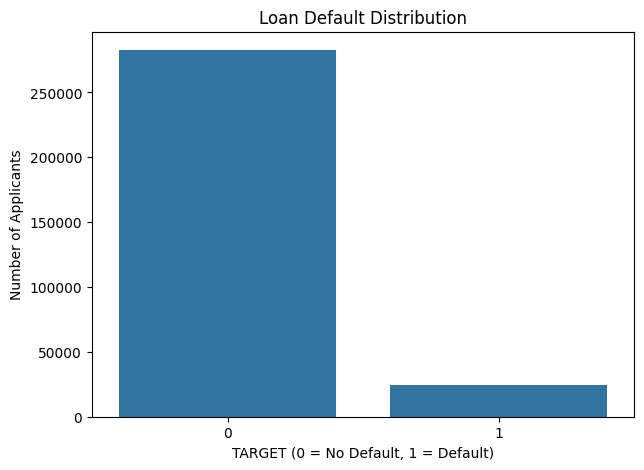

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=application_train,
    x="TARGET"
)

plt.title("Loan Default Distribution")
plt.xlabel("TARGET (0 = No Default, 1 = Default)")
plt.ylabel("Number of Applicants")

plt.show()

In [16]:
default_rate = application_train["TARGET"].mean() * 100

print(f"Overall default rate: {default_rate:.2f}%")

Overall default rate: 8.07%


In [17]:
# 3.4 Feature Categorization

numerical_features = application_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = application_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 106
Categorical features: 16


In [18]:
numerical_features = [
    col for col in numerical_features
    if col != "TARGET"
]

print("Predictor numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Predictor numerical features: 105
Categorical features: 16


In [19]:
print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_M

In [20]:
# 3.5 Missing Value Analysis

missing = pd.DataFrame({
    "Missing Count": application_train.isnull().sum(),
    "Missing %": application_train.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing %",
    ascending=False
)

missing.head(30)

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.8723
COMMONAREA_MODE,214865,69.8723
COMMONAREA_MEDI,214865,69.8723
NONLIVINGAPARTMENTS_MEDI,213514,69.4330
NONLIVINGAPARTMENTS_MODE,213514,69.4330
NONLIVINGAPARTMENTS_AVG,213514,69.4330
FONDKAPREMONT_MODE,210295,68.3862
LIVINGAPARTMENTS_AVG,210199,68.3550
LIVINGAPARTMENTS_MEDI,210199,68.3550
LIVINGAPARTMENTS_MODE,210199,68.3550


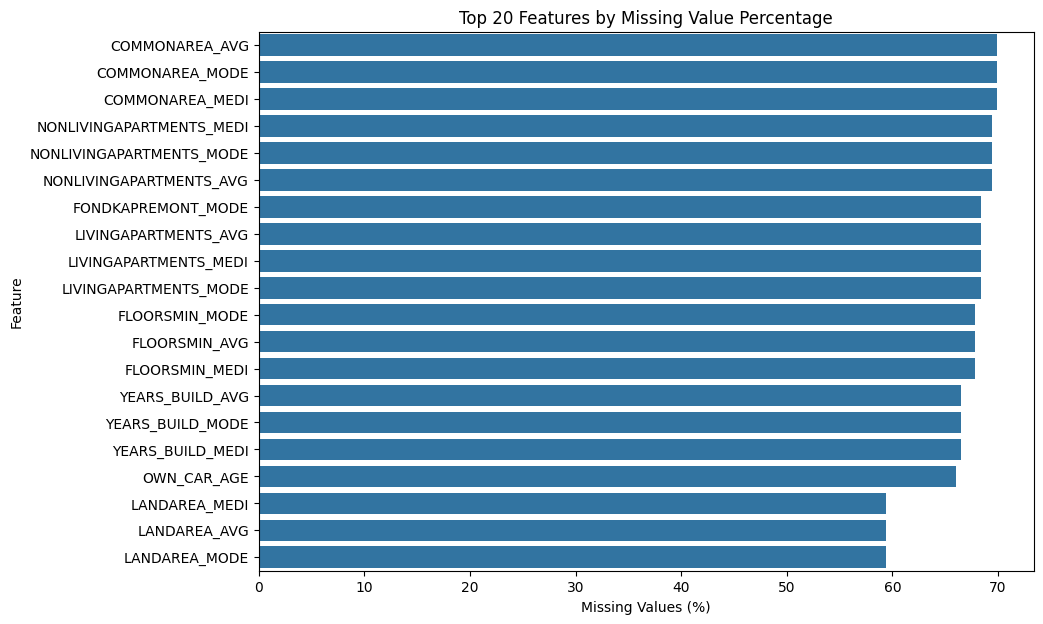

In [21]:
missing_top = missing[
    missing["Missing Count"] > 0
].head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=missing_top["Missing %"],
    y=missing_top.index
)

plt.title("Top 20 Features by Missing Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.show()

In [22]:
# 3.6 Duplicate Analysis

duplicate_count = application_train.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [23]:
print(
    "Duplicate SK_ID_CURR:",
    application_train["SK_ID_CURR"].duplicated().sum()
)

Duplicate SK_ID_CURR: 0


In [24]:
# DATASET INVENTORY - ALL CSV FILES

import os
import pandas as pd

csv_files = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv"
]

dataset_info = []

for file in csv_files:
    file_path = os.path.join(path, file)
    
    df_temp = pd.read_csv(file_path, nrows=5)
    
    with open(file_path, "rb") as f:
        row_count = sum(1 for _ in f) - 1
    
    dataset_info.append({
        "File": file,
        "Rows": row_count,
        "Columns": df_temp.shape[1],
        "Has SK_ID_CURR": "SK_ID_CURR" in df_temp.columns,
        "Columns Preview": list(df_temp.columns[:8])
    })

dataset_summary = pd.DataFrame(dataset_info)

dataset_summary

,File,Rows,Columns,Has SK_ID_CURR,Columns Preview
0,application_train.csv,307511,122,True,"[SK_ID_CURR, TARGET, NAME_CONTRACT_TYPE, CODE_..."
1,application_test.csv,48744,121,True,"[SK_ID_CURR, NAME_CONTRACT_TYPE, CODE_GENDER, ..."
2,bureau.csv,1716428,17,True,"[SK_ID_CURR, SK_ID_BUREAU, CREDIT_ACTIVE, CRED..."
3,bureau_balance.csv,27299925,3,False,"[SK_ID_BUREAU, MONTHS_BALANCE, STATUS]"
4,previous_application.csv,1670214,37,True,"[SK_ID_PREV, SK_ID_CURR, NAME_CONTRACT_TYPE, A..."
5,POS_CASH_balance.csv,10001358,8,True,"[SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, CNT_I..."
6,credit_card_balance.csv,3840312,23,True,"[SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, AMT_B..."
7,installments_payments.csv,13605401,8,True,"[SK_ID_PREV, SK_ID_CURR, NUM_INSTALMENT_VERSIO..."


In [25]:
# BUREAU DATASET - INITIAL INSPECTION

bureau_path = os.path.join(path, "bureau.csv")

bureau = pd.read_csv(bureau_path)

print("Shape:", bureau.shape)
print("\nData Types:")
print(bureau.dtypes)

print("\nFirst 5 rows:")
display(bureau.head())

print("\nMissing Values:")
display(
    bureau.isnull()
         .mean()
         .sort_values(ascending=False)
         .to_frame("Missing_Percentage")
         .head(20)
)

Shape: (1716428, 17)

Data Types:
SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE              object
CREDIT_CURRENCY            object
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                object
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object

First 5 rows:


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,91323.0000,0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0000,NaN,NaN,0,225000.0000,171342.0000,NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,464323.5000,NaN,NaN,0.0000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0000,NaN,NaN,0.0000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0000,NaN,77674.5000,0,2700000.0000,NaN,NaN,0.0000,Consumer credit,-21,NaN



Missing Values:


,Missing_Percentage
AMT_ANNUITY,0.7147
AMT_CREDIT_MAX_OVERDUE,0.6551
DAYS_ENDDATE_FACT,0.3692
AMT_CREDIT_SUM_LIMIT,0.3448
AMT_CREDIT_SUM_DEBT,0.1501
DAYS_CREDIT_ENDDATE,0.0615
AMT_CREDIT_SUM,0.0000
SK_ID_CURR,0.0000
SK_ID_BUREAU,0.0000
CREDIT_DAY_OVERDUE,0.0000


In [26]:
# Categorical columns and their unique values

categorical_cols = bureau.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", bureau[col].nunique())
    print(bureau[col].value_counts(dropna=False).head(10))


--- CREDIT_ACTIVE ---
Unique values: 4
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

--- CREDIT_CURRENCY ---
Unique values: 4
CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

--- CREDIT_TYPE ---
Unique values: 15
CREDIT_TYPE
Consumer credit                           1251615
Credit card                                402195
Car loan                                    27690
Mortgage                                    18391
Microloan                                   12413
Loan for business development                1975
Another type of loan                         1017
Unknown type of loan                          555
Loan for working capital replenishment        469
Cash loan (non-earmarked)                      56
Name: count, dtype: int64


In [27]:
# Numerical summary

bureau.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.0000,278214.9336,102938.5581,100001.0000,188866.7500,278055.0000,367426.0000,456255.0000
SK_ID_BUREAU,1716428.0000,5924434.4890,532265.7286,5000000.0000,5463953.7500,5926303.5000,6385681.2500,6843457.0000
DAYS_CREDIT,1716428.0000,-1142.1077,795.1649,-2922.0000,-1666.0000,-987.0000,-474.0000,0.0000
CREDIT_DAY_OVERDUE,1716428.0000,0.8182,36.5444,0.0000,0.0000,0.0000,0.0000,2792.0000
DAYS_CREDIT_ENDDATE,1610875.0000,510.5174,4994.2198,-42060.0000,-1138.0000,-330.0000,474.0000,31199.0000
DAYS_ENDDATE_FACT,1082775.0000,-1017.4371,714.0106,-42023.0000,-1489.0000,-897.0000,-425.0000,0.0000
AMT_CREDIT_MAX_OVERDUE,591940.0000,3825.4177,206031.6062,0.0000,0.0000,0.0000,0.0000,115987185.0000
CNT_CREDIT_PROLONG,1716428.0000,0.0064,0.0962,0.0000,0.0000,0.0000,0.0000,9.0000
AMT_CREDIT_SUM,1716415.0000,354994.5919,1149811.3440,0.0000,51300.0000,125518.5000,315000.0000,585000000.0000
AMT_CREDIT_SUM_DEBT,1458759.0000,137085.1200,677401.1310,-4705600.3200,0.0000,0.0000,40153.5000,170100000.0000


In [28]:
# BUREAU CREDIT STATUS ANALYSIS

# Connect bureau records with applicant TARGET
bureau_target = bureau.merge(
    application_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="left"
)

# Default rate by credit status
bureau_target.groupby("CREDIT_ACTIVE")["TARGET"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False)

,count,mean
CREDIT_ACTIVE,,
Bad debt,20,0.2000
Sold,5653,0.1010
Active,541919,0.0929
Closed,917733,0.0693


In [29]:
# OVERDUE CREDIT ANALYSIS

bureau_target["HAS_OVERDUE"] = (
    bureau_target["CREDIT_DAY_OVERDUE"] > 0
).astype(int)

bureau_target.groupby("HAS_OVERDUE")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
HAS_OVERDUE,,
0,1461619,0.0779
1,3706,0.1821


In [30]:
# Amount overdue
bureau_target["HAS_OVERDUE_AMOUNT"] = (
    bureau_target["AMT_CREDIT_SUM_OVERDUE"] > 0
).astype(int)

bureau_target.groupby("HAS_OVERDUE_AMOUNT")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
HAS_OVERDUE_AMOUNT,,
0,1461681,0.0779
1,3644,0.1869


In [31]:
# BUREAU FEATURE AGGREGATION

bureau_features = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT=("SK_ID_BUREAU", "count"),

    # Credit status
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    BUREAU_SOLD_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Sold").sum()),

    # Credit history
    BUREAU_AVG_DAYS_CREDIT=("DAYS_CREDIT", "mean"),
    BUREAU_MIN_DAYS_CREDIT=("DAYS_CREDIT", "min"),

    # Credit amounts
    BUREAU_TOTAL_CREDIT=("AMT_CREDIT_SUM", "sum"),
    BUREAU_AVG_CREDIT=("AMT_CREDIT_SUM", "mean"),
    BUREAU_MAX_CREDIT=("AMT_CREDIT_SUM", "max"),

    # Debt
    BUREAU_TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_AVG_DEBT=("AMT_CREDIT_SUM_DEBT", "mean"),

    # Credit limits
    BUREAU_TOTAL_LIMIT=("AMT_CREDIT_SUM_LIMIT", "sum"),
    BUREAU_AVG_LIMIT=("AMT_CREDIT_SUM_LIMIT", "mean"),

    # Overdue
    BUREAU_TOTAL_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    BUREAU_MAX_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "max"),

    BUREAU_OVERDUE_COUNT=(
        "AMT_CREDIT_SUM_OVERDUE",
        lambda x: (x > 0).sum()
    ),

    BUREAU_DAYS_OVERDUE_MAX=(
        "CREDIT_DAY_OVERDUE",
        "max"
    ),

    # Credit prolongation
    BUREAU_TOTAL_PROLONG=("CNT_CREDIT_PROLONG", "sum"),
    BUREAU_MAX_PROLONG=("CNT_CREDIT_PROLONG", "max")
).reset_index()

print("Shape:", bureau_features.shape)

display(bureau_features.head())

Shape: (305811, 20)


,SK_ID_CURR,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_CLOSED_COUNT,BUREAU_SOLD_COUNT,BUREAU_AVG_DAYS_CREDIT,BUREAU_MIN_DAYS_CREDIT,BUREAU_TOTAL_CREDIT,BUREAU_AVG_CREDIT,BUREAU_MAX_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_AVG_DEBT,BUREAU_TOTAL_LIMIT,BUREAU_AVG_LIMIT,BUREAU_TOTAL_OVERDUE,BUREAU_MAX_OVERDUE,BUREAU_OVERDUE_COUNT,BUREAU_DAYS_OVERDUE_MAX,BUREAU_TOTAL_PROLONG,BUREAU_MAX_PROLONG
0,100001,7,3,4,0,-735.0000,-1572,1453365.0000,207623.5714,378000.0000,596686.5000,85240.9286,0.0000,0.0000,0.0000,0.0000,0,0,0,0
1,100002,8,2,6,0,-874.0000,-1437,865055.5650,108131.9456,450000.0000,245781.0000,49156.2000,31988.5650,7997.1412,0.0000,0.0000,0,0,0,0
2,100003,4,1,3,0,-1400.7500,-2586,1017400.5000,254350.1250,810000.0000,0.0000,0.0000,810000.0000,202500.0000,0.0000,0.0000,0,0,0,0
3,100004,2,0,2,0,-867.0000,-1326,189037.8000,94518.9000,94537.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0
4,100005,3,2,1,0,-190.6667,-373,657126.0000,219042.0000,568800.0000,568408.5000,189469.5000,0.0000,0.0000,0.0000,0.0000,0,0,0,0


In [32]:
# BUREAU BALANCE - INITIAL INSPECTION

bureau_balance_path = os.path.join(path, "bureau_balance.csv")

bureau_balance_sample = pd.read_csv(
    bureau_balance_path,
    nrows=100000
)

print("Sample shape:", bureau_balance_sample.shape)

print("\nData types:")
print(bureau_balance_sample.dtypes)

print("\nFirst 10 rows:")
display(bureau_balance_sample.head(10))

print("\nSTATUS distribution:")
display(
    bureau_balance_sample["STATUS"]
    .value_counts(dropna=False)
)

Sample shape: (100000, 3)

Data types:
SK_ID_BUREAU       int64
MONTHS_BALANCE     int64
STATUS            object
dtype: object

First 10 rows:


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
5,5715448,-5,C
6,5715448,-6,C
7,5715448,-7,C
8,5715448,-8,C
9,5715448,-9,0



STATUS distribution:


STATUS
C    47434
0    28090
X    23307
1      963
2       96
5       71
3       23
4       16
Name: count, dtype: int64

In [33]:
# MONTHLY STATUS MEANING / DISTRIBUTION

print("Unique STATUS values:")
print(bureau_balance_sample["STATUS"].unique())

print("\nMONTHS_BALANCE summary:")
display(
    bureau_balance_sample["MONTHS_BALANCE"].describe()
)

Unique STATUS values:
['C' '0' 'X' '1' '2' '3' '5' '4']

MONTHS_BALANCE summary:


count   100000.0000
mean       -28.5152
std         22.7032
min        -96.0000
25%        -42.0000
50%        -23.0000
75%        -10.0000
max          0.0000
Name: MONTHS_BALANCE, dtype: float64

In [34]:
# BUREAU BALANCE FEATURE ENGINEERING
# Process 27M+ rows in chunks

bureau_balance_path = os.path.join(path, "bureau_balance.csv")

chunk_size = 500_000
bureau_balance_parts = []

for chunk in pd.read_csv(bureau_balance_path, chunksize=chunk_size):

    # Flag delinquent statuses
    chunk["IS_OVERDUE"] = chunk["STATUS"].isin(
        ["1", "2", "3", "4", "5"]
    ).astype("int8")

    # Flag severe delinquency
    chunk["IS_SEVERE_OVERDUE"] = chunk["STATUS"].isin(
        ["3", "4", "5"]
    ).astype("int8")

    # Flag normal/closed status
    chunk["IS_NORMAL"] = chunk["STATUS"].isin(
        ["0", "C"]
    ).astype("int8")

    # Aggregate within this chunk
    part = chunk.groupby("SK_ID_BUREAU").agg(
        BUREAU_MONTH_COUNT=("MONTHS_BALANCE", "count"),
        BUREAU_OVERDUE_MONTHS=("IS_OVERDUE", "sum"),
        BUREAU_SEVERE_OVERDUE_MONTHS=("IS_SEVERE_OVERDUE", "sum"),
        BUREAU_NORMAL_MONTHS=("IS_NORMAL", "sum"),
        BUREAU_OLDEST_MONTH=("MONTHS_BALANCE", "min"),
        BUREAU_LATEST_MONTH=("MONTHS_BALANCE", "max")
    )

    bureau_balance_parts.append(part)

    print(
        f"Processed chunk | "
        f"rows: {len(chunk):,} | "
        f"bureau IDs: {len(part):,}"
    )

Processed chunk | rows: 500,000 | bureau IDs: 14,829
Processed chunk | rows: 500,000 | bureau IDs: 14,835
Processed chunk | rows: 500,000 | bureau IDs: 14,323
Processed chunk | rows: 500,000 | bureau IDs: 14,567
Processed chunk | rows: 500,000 | bureau IDs: 14,562
Processed chunk | rows: 500,000 | bureau IDs: 14,603
Processed chunk | rows: 500,000 | bureau IDs: 14,275
Processed chunk | rows: 500,000 | bureau IDs: 14,975
Processed chunk | rows: 500,000 | bureau IDs: 14,826
Processed chunk | rows: 500,000 | bureau IDs: 14,219
Processed chunk | rows: 500,000 | bureau IDs: 14,443
Processed chunk | rows: 500,000 | bureau IDs: 14,616
Processed chunk | rows: 500,000 | bureau IDs: 14,511
Processed chunk | rows: 500,000 | bureau IDs: 15,272
Processed chunk | rows: 500,000 | bureau IDs: 14,233
Processed chunk | rows: 500,000 | bureau IDs: 15,227
Processed chunk | rows: 500,000 | bureau IDs: 14,905
Processed chunk | rows: 500,000 | bureau IDs: 15,127
Processed chunk | rows: 500,000 | bureau IDs: 

In [35]:
# COMBINE CHUNK RESULTS
bureau_balance_features = pd.concat(bureau_balance_parts)

bureau_balance_features = bureau_balance_features.groupby(
    level=0
).agg({
    "BUREAU_MONTH_COUNT": "sum",
    "BUREAU_OVERDUE_MONTHS": "sum",
    "BUREAU_SEVERE_OVERDUE_MONTHS": "sum",
    "BUREAU_NORMAL_MONTHS": "sum",
    "BUREAU_OLDEST_MONTH": "min",
    "BUREAU_LATEST_MONTH": "max"
})

# Calculate useful ratios
bureau_balance_features["BUREAU_OVERDUE_RATIO"] = (
    bureau_balance_features["BUREAU_OVERDUE_MONTHS"]
    / bureau_balance_features["BUREAU_MONTH_COUNT"]
)

bureau_balance_features["BUREAU_SEVERE_OVERDUE_RATIO"] = (
    bureau_balance_features["BUREAU_SEVERE_OVERDUE_MONTHS"]
    / bureau_balance_features["BUREAU_MONTH_COUNT"]
)

print("Shape:", bureau_balance_features.shape)

display(bureau_balance_features.head())

Shape: (817395, 8)


,BUREAU_MONTH_COUNT,BUREAU_OVERDUE_MONTHS,BUREAU_SEVERE_OVERDUE_MONTHS,BUREAU_NORMAL_MONTHS,BUREAU_OLDEST_MONTH,BUREAU_LATEST_MONTH,BUREAU_OVERDUE_RATIO,BUREAU_SEVERE_OVERDUE_RATIO
SK_ID_BUREAU,,,,,,,,
5001709,97,0,0,86,-96,0,0.0000,0.0000
5001710,83,0,0,53,-82,0,0.0000,0.0000
5001711,4,0,0,3,-3,0,0.0000,0.0000
5001712,19,0,0,19,-18,0,0.0000,0.0000
5001713,22,0,0,0,-21,0,0.0000,0.0000


In [36]:
# MERGE BUREAU BALANCE WITH BUREAU

bureau_with_balance = bureau[
    ["SK_ID_CURR", "SK_ID_BUREAU"]
].merge(
    bureau_balance_features,
    left_on="SK_ID_BUREAU",
    right_index=True,
    how="left"
)

print("Shape:", bureau_with_balance.shape)

display(bureau_with_balance.head())

Shape: (1716428, 10)


,SK_ID_CURR,SK_ID_BUREAU,BUREAU_MONTH_COUNT,BUREAU_OVERDUE_MONTHS,BUREAU_SEVERE_OVERDUE_MONTHS,BUREAU_NORMAL_MONTHS,BUREAU_OLDEST_MONTH,BUREAU_LATEST_MONTH,BUREAU_OVERDUE_RATIO,BUREAU_SEVERE_OVERDUE_RATIO
0,215354,5714462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# APPLICANT-LEVEL BUREAU BALANCE FEATURES

bureau_balance_applicant = bureau_with_balance.groupby(
    "SK_ID_CURR"
).agg(
    BUREAU_TOTAL_MONTHS=("BUREAU_MONTH_COUNT", "sum"),
    BUREAU_TOTAL_OVERDUE_MONTHS=("BUREAU_OVERDUE_MONTHS", "sum"),
    BUREAU_TOTAL_SEVERE_OVERDUE_MONTHS=(
        "BUREAU_SEVERE_OVERDUE_MONTHS",
        "sum"
    ),

    BUREAU_AVG_OVERDUE_RATIO=(
        "BUREAU_OVERDUE_RATIO",
        "mean"
    ),

    BUREAU_MAX_OVERDUE_RATIO=(
        "BUREAU_OVERDUE_RATIO",
        "max"
    ),

    BUREAU_AVG_SEVERE_OVERDUE_RATIO=(
        "BUREAU_SEVERE_OVERDUE_RATIO",
        "mean"
    )
).reset_index()

print("Shape:", bureau_balance_applicant.shape)

display(bureau_balance_applicant.head())

Shape: (305811, 7)


,SK_ID_CURR,BUREAU_TOTAL_MONTHS,BUREAU_TOTAL_OVERDUE_MONTHS,BUREAU_TOTAL_SEVERE_OVERDUE_MONTHS,BUREAU_AVG_OVERDUE_RATIO,BUREAU_MAX_OVERDUE_RATIO,BUREAU_AVG_SEVERE_OVERDUE_RATIO
0,100001,172.0000,1.0000,0.0000,0.0075,0.0526,0.0000
1,100002,110.0000,27.0000,0.0000,0.2557,0.5000,0.0000
2,100003,0.0000,0.0000,0.0000,NaN,NaN,NaN
3,100004,0.0000,0.0000,0.0000,NaN,NaN,NaN
4,100005,21.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [38]:
# PREVIOUS APPLICATION - INITIAL INSPECTION

previous_path = os.path.join(
    path,
    "previous_application.csv"
)

previous_application = pd.read_csv(previous_path)

print("Shape:", previous_application.shape)

print("\nData Types:")
print(previous_application.dtypes)

print("\nFirst 5 rows:")
display(previous_application.head())

print("\nMissing Values:")
display(
    previous_application.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

Shape: (1670214, 37)

Data Types:
SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE              object
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START      object
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT     object
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE          object
NAME_CONTRACT_STATUS            object
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE               object
CODE_REJECT_REASON              object
NAME_TYPE_SUITE                 object
NAME_CLIENT_TYPE                object
NAME_GOODS_CATEGORY             object
NAME_PORTFOLIO                  object
NAME_PRODUCT_TYPE             

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.4300,17145.0000,17145.0000,0.0000,17145.0000,SATURDAY,15,Y,1,0.0000,0.1828,0.8673,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0000,middle,POS mobile with interest,365243.0000,-42.0000,300.0000,-42.0000,-37.0000,0.0000
1,2802425,108129,Cash loans,25188.6150,607500.0000,679671.0000,NaN,607500.0000,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0000,low_action,Cash X-Sell: low,365243.0000,-134.0000,916.0000,365243.0000,365243.0000,1.0000
2,2523466,122040,Cash loans,15060.7350,112500.0000,136444.5000,NaN,112500.0000,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,high,Cash X-Sell: high,365243.0000,-271.0000,59.0000,365243.0000,365243.0000,1.0000
3,2819243,176158,Cash loans,47041.3350,450000.0000,470790.0000,NaN,450000.0000,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,middle,Cash X-Sell: middle,365243.0000,-482.0000,-152.0000,-182.0000,-177.0000,1.0000
4,1784265,202054,Cash loans,31924.3950,337500.0000,404055.0000,NaN,337500.0000,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0000,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN



Missing Values:


RATE_INTEREST_PRIVILEGED    0.9964
RATE_INTEREST_PRIMARY       0.9964
AMT_DOWN_PAYMENT            0.5364
RATE_DOWN_PAYMENT           0.5364
NAME_TYPE_SUITE             0.4912
DAYS_TERMINATION            0.4030
DAYS_FIRST_DRAWING          0.4030
DAYS_FIRST_DUE              0.4030
DAYS_LAST_DUE_1ST_VERSION   0.4030
DAYS_LAST_DUE               0.4030
NFLAG_INSURED_ON_APPROVAL   0.4030
AMT_GOODS_PRICE             0.2308
AMT_ANNUITY                 0.2229
CNT_PAYMENT                 0.2229
PRODUCT_COMBINATION         0.0002
AMT_CREDIT                  0.0000
SK_ID_PREV                  0.0000
AMT_APPLICATION             0.0000
NAME_CONTRACT_TYPE          0.0000
SK_ID_CURR                  0.0000
dtype: float64

In [39]:
# CATEGORICAL VARIABLES

categorical_cols = previous_application.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", previous_application[col].nunique())
    print(
        previous_application[col]
        .value_counts(dropna=False)
        .head(10)
    )


--- NAME_CONTRACT_TYPE ---
Unique values: 4
NAME_CONTRACT_TYPE
Cash loans         747553
Consumer loans     729151
Revolving loans    193164
XNA                   346
Name: count, dtype: int64

--- WEEKDAY_APPR_PROCESS_START ---
Unique values: 7
WEEKDAY_APPR_PROCESS_START
TUESDAY      255118
WEDNESDAY    255010
MONDAY       253557
FRIDAY       252048
THURSDAY     249099
SATURDAY     240631
SUNDAY       164751
Name: count, dtype: int64

--- FLAG_LAST_APPL_PER_CONTRACT ---
Unique values: 2
FLAG_LAST_APPL_PER_CONTRACT
Y    1661739
N       8475
Name: count, dtype: int64

--- NAME_CASH_LOAN_PURPOSE ---
Unique values: 25
NAME_CASH_LOAN_PURPOSE
XAP                             922661
XNA                             677918
Repairs                          23765
Other                            15608
Urgent needs                      8412
Buying a used car                 2888
Building a house or an annex      2693
Everyday expenses                 2416
Medicine                          2174
Pa

In [40]:
# NUMERICAL SUMMARY

previous_application.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,1670214.0000,1923089.1353,532597.9587,1000001.0000,1461857.2500,1923110.5000,2384279.7500,2845382.0000
SK_ID_CURR,1670214.0000,278357.1741,102814.8238,100001.0000,189329.0000,278714.5000,367514.0000,456255.0000
AMT_ANNUITY,1297979.0000,15955.1207,14782.1373,0.0000,6321.7800,11250.0000,20658.4200,418058.1450
AMT_APPLICATION,1670214.0000,175233.8604,292779.7624,0.0000,18720.0000,71046.0000,180360.0000,6905160.0000
AMT_CREDIT,1670213.0000,196114.0212,318574.6165,0.0000,24160.5000,80541.0000,216418.5000,6905160.0000
AMT_DOWN_PAYMENT,774370.0000,6697.4021,20921.4954,-0.9000,0.0000,1638.0000,7740.0000,3060045.0000
AMT_GOODS_PRICE,1284699.0000,227847.2793,315396.5579,0.0000,50841.0000,112320.0000,234000.0000,6905160.0000
HOUR_APPR_PROCESS_START,1670214.0000,12.4842,3.3340,0.0000,10.0000,12.0000,15.0000,23.0000
NFLAG_LAST_APPL_IN_DAY,1670214.0000,0.9965,0.0593,0.0000,1.0000,1.0000,1.0000,1.0000
RATE_DOWN_PAYMENT,774370.0000,0.0796,0.1078,-0.0000,0.0000,0.0516,0.1089,1.0000


In [41]:
# PREVIOUS APPLICATION FEATURE ENGINEERING

previous_application["CREDIT_TO_APPLICATION_RATIO"] = (
    previous_application["AMT_CREDIT"]
    / previous_application["AMT_APPLICATION"].replace(0, np.nan)
)

previous_application["HAS_DOWN_PAYMENT"] = (
    previous_application["AMT_DOWN_PAYMENT"].fillna(0) > 0
).astype("int8")

previous_application["IS_APPROVED"] = (
    previous_application["NAME_CONTRACT_STATUS"] == "Approved"
).astype("int8")

previous_application["IS_REFUSED"] = (
    previous_application["NAME_CONTRACT_STATUS"] == "Refused"
).astype("int8")

previous_application["IS_CANCELLED"] = (
    previous_application["NAME_CONTRACT_STATUS"] == "Canceled"
).astype("int8")

previous_features = previous_application.groupby(
    "SK_ID_CURR"
).agg(
    # Number of previous applications
    PREV_APP_COUNT=("SK_ID_PREV", "count"),

    # Application outcomes
    PREV_APPROVED_COUNT=("IS_APPROVED", "sum"),
    PREV_REFUSED_COUNT=("IS_REFUSED", "sum"),
    PREV_CANCELLED_COUNT=("IS_CANCELLED", "sum"),

    # Amounts
    PREV_AVG_APPLICATION=("AMT_APPLICATION", "mean"),
    PREV_AVG_CREDIT=("AMT_CREDIT", "mean"),
    PREV_TOTAL_CREDIT=("AMT_CREDIT", "sum"),
    PREV_MAX_CREDIT=("AMT_CREDIT", "max"),

    PREV_AVG_ANNUITY=("AMT_ANNUITY", "mean"),
    PREV_AVG_DOWN_PAYMENT=("AMT_DOWN_PAYMENT", "mean"),

    # Ratios / behaviour
    PREV_AVG_CREDIT_APPLICATION_RATIO=(
        "CREDIT_TO_APPLICATION_RATIO",
        "mean"
    ),

    PREV_DOWN_PAYMENT_COUNT=(
        "HAS_DOWN_PAYMENT",
        "sum"
    )
).reset_index()

# Calculate rates
previous_features["PREV_APPROVAL_RATE"] = (
    previous_features["PREV_APPROVED_COUNT"]
    / previous_features["PREV_APP_COUNT"]
)

previous_features["PREV_REFUSAL_RATE"] = (
    previous_features["PREV_REFUSED_COUNT"]
    / previous_features["PREV_APP_COUNT"]
)

print("Shape:", previous_features.shape)

display(previous_features.head())

Shape: (338857, 15)


,SK_ID_CURR,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_CANCELLED_COUNT,PREV_AVG_APPLICATION,PREV_AVG_CREDIT,PREV_TOTAL_CREDIT,PREV_MAX_CREDIT,PREV_AVG_ANNUITY,PREV_AVG_DOWN_PAYMENT,PREV_AVG_CREDIT_APPLICATION_RATIO,PREV_DOWN_PAYMENT_COUNT,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE
0,100001,1,1,0,0,24835.5000,23787.0000,23787.0000,23787.0000,3951.0000,2520.0000,0.9578,1,1.0000,0.0000
1,100002,1,1,0,0,179055.0000,179055.0000,179055.0000,179055.0000,9251.7750,0.0000,1.0000,0,1.0000,0.0000
2,100003,3,3,0,0,435436.5000,484191.0000,1452573.0000,1035882.0000,56553.9900,3442.5000,1.0577,1,1.0000,0.0000
3,100004,1,1,0,0,24282.0000,20106.0000,20106.0000,20106.0000,5357.2500,4860.0000,0.8280,1,1.0000,0.0000
4,100005,2,1,0,1,22308.7500,20076.7500,40153.5000,40153.5000,4813.2000,4464.0000,0.8999,1,0.5000,0.0000


In [42]:
# PREVIOUS APPLICATION OUTCOME vs TARGET

prev_target = previous_application.merge(
    application_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="left"
)

prev_target.groupby(
    "NAME_CONTRACT_STATUS"
)["TARGET"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

,count,mean
NAME_CONTRACT_STATUS,,
Refused,245390,0.1200
Canceled,259441,0.0917
Unused offer,22771,0.0825
Approved,886099,0.0759


In [43]:
pos_path = os.path.join(path, "POS_CASH_balance.csv")

pos = pd.read_csv(pos_path)

print("Shape:", pos.shape)
print("\nColumns:")
print(pos.columns.tolist())

print("\nData types:")
print(pos.dtypes)

print("\nMissing values:")
print(
    pos.isnull()
       .mean()
       .mul(100)
       .sort_values(ascending=False)
       .head(15)
)

print("\nCategorical distributions:")

for col in pos.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(pos[col].value_counts(dropna=False).head(15))

print("\nNumerical summary:")
display(pos.describe().T)

Shape: (10001358, 8)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Data types:
SK_ID_PREV                 int64
SK_ID_CURR                 int64
MONTHS_BALANCE             int64
CNT_INSTALMENT           float64
CNT_INSTALMENT_FUTURE    float64
NAME_CONTRACT_STATUS      object
SK_DPD                     int64
SK_DPD_DEF                 int64
dtype: object

Missing values:
CNT_INSTALMENT_FUTURE   0.2608
CNT_INSTALMENT          0.2607
SK_ID_CURR              0.0000
SK_ID_PREV              0.0000
MONTHS_BALANCE          0.0000
NAME_CONTRACT_STATUS    0.0000
SK_DPD                  0.0000
SK_DPD_DEF              0.0000
dtype: float64

Categorical distributions:

--- NAME_CONTRACT_STATUS ---
NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved        

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,10001358.0000,1903216.5990,535846.5307,1000001.0000,1434405.0000,1896565.0000,2368963.0000,2843499.0000
SK_ID_CURR,10001358.0000,278403.8633,102763.7451,100001.0000,189550.0000,278654.0000,367429.0000,456255.0000
MONTHS_BALANCE,10001358.0000,-35.0126,26.0666,-96.0000,-54.0000,-28.0000,-13.0000,-1.0000
CNT_INSTALMENT,9975287.0000,17.0897,11.9951,1.0000,10.0000,12.0000,24.0000,92.0000
CNT_INSTALMENT_FUTURE,9975271.0000,10.4838,11.1091,0.0000,3.0000,7.0000,14.0000,85.0000
SK_DPD,10001358.0000,11.6069,132.7140,0.0000,0.0000,0.0000,0.0000,4231.0000
SK_DPD_DEF,10001358.0000,0.6545,32.7625,0.0000,0.0000,0.0000,0.0000,3595.0000


In [44]:
del pos
import gc
gc.collect()

0

In [45]:
pos_path = os.path.join(path, "POS_CASH_balance.csv")

pos_parts = []

for chunk in pd.read_csv(
    pos_path,
    usecols=[
        "SK_ID_CURR",
        "SK_ID_PREV",
        "MONTHS_BALANCE",
        "CNT_INSTALMENT",
        "CNT_INSTALMENT_FUTURE",
        "NAME_CONTRACT_STATUS",
        "SK_DPD",
        "SK_DPD_DEF"
    ],
    chunksize=500_000
):
    
    # Delinquency indicators
    chunk["HAS_DPD"] = (chunk["SK_DPD"] > 0).astype("int8")
    chunk["HAS_DPD_DEF"] = (chunk["SK_DPD_DEF"] > 0).astype("int8")
    
    # Contract status indicators
    chunk["IS_ACTIVE"] = (
        chunk["NAME_CONTRACT_STATUS"] == "Active"
    ).astype("int8")
    
    chunk["IS_COMPLETED"] = (
        chunk["NAME_CONTRACT_STATUS"] == "Completed"
    ).astype("int8")
    
    part = chunk.groupby("SK_ID_CURR").agg(
        POS_CONTRACT_COUNT=("SK_ID_PREV", "nunique"),
        
        POS_MONTH_COUNT=("MONTHS_BALANCE", "count"),
        
        POS_AVG_DPD=("SK_DPD", "mean"),
        POS_MAX_DPD=("SK_DPD", "max"),
        
        POS_DPD_MONTHS=("HAS_DPD", "sum"),
        POS_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum"),
        
        POS_AVG_DPD_DEF=("SK_DPD_DEF", "mean"),
        POS_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
        
        POS_ACTIVE_COUNT=("IS_ACTIVE", "sum"),
        POS_COMPLETED_COUNT=("IS_COMPLETED", "sum"),
        
        POS_AVG_INSTALLMENTS=("CNT_INSTALMENT", "mean"),
        POS_AVG_FUTURE_INSTALLMENTS=("CNT_INSTALMENT_FUTURE", "mean"),
        
        POS_MIN_FUTURE_INSTALLMENTS=("CNT_INSTALMENT_FUTURE", "min")
    )
    
    pos_parts.append(part)

    print("Processed:", len(pos_parts), "chunks")

Processed: 1 chunks
Processed: 2 chunks
Processed: 3 chunks
Processed: 4 chunks
Processed: 5 chunks
Processed: 6 chunks
Processed: 7 chunks
Processed: 8 chunks
Processed: 9 chunks
Processed: 10 chunks
Processed: 11 chunks
Processed: 12 chunks
Processed: 13 chunks
Processed: 14 chunks
Processed: 15 chunks
Processed: 16 chunks
Processed: 17 chunks
Processed: 18 chunks
Processed: 19 chunks
Processed: 20 chunks
Processed: 21 chunks


In [46]:
pos_features = pd.concat(pos_parts)

pos_features = pos_features.groupby(level=0).agg({
    "POS_CONTRACT_COUNT": "sum",
    "POS_MONTH_COUNT": "sum",
    "POS_AVG_DPD": "mean",
    "POS_MAX_DPD": "max",
    "POS_DPD_MONTHS": "sum",
    "POS_DPD_DEF_MONTHS": "sum",
    "POS_AVG_DPD_DEF": "mean",
    "POS_MAX_DPD_DEF": "max",
    "POS_ACTIVE_COUNT": "sum",
    "POS_COMPLETED_COUNT": "sum",
    "POS_AVG_INSTALLMENTS": "mean",
    "POS_AVG_FUTURE_INSTALLMENTS": "mean",
    "POS_MIN_FUTURE_INSTALLMENTS": "min"
}).reset_index()

In [47]:
pos_features["POS_DPD_RATIO"] = (
    pos_features["POS_DPD_MONTHS"] /
    pos_features["POS_MONTH_COUNT"]
)

pos_features["POS_DPD_DEF_RATIO"] = (
    pos_features["POS_DPD_DEF_MONTHS"] /
    pos_features["POS_MONTH_COUNT"]
)

pos_features["POS_ACTIVE_RATIO"] = (
    pos_features["POS_ACTIVE_COUNT"] /
    pos_features["POS_MONTH_COUNT"]
)

print("Shape:", pos_features.shape)

display(pos_features.head())

Shape: (337252, 17)


,SK_ID_CURR,POS_CONTRACT_COUNT,POS_MONTH_COUNT,POS_AVG_DPD,POS_MAX_DPD,POS_DPD_MONTHS,POS_DPD_DEF_MONTHS,POS_AVG_DPD_DEF,POS_MAX_DPD_DEF,POS_ACTIVE_COUNT,POS_COMPLETED_COUNT,POS_AVG_INSTALLMENTS,POS_AVG_FUTURE_INSTALLMENTS,POS_MIN_FUTURE_INSTALLMENTS,POS_DPD_RATIO,POS_DPD_DEF_RATIO,POS_ACTIVE_RATIO
0,100001,9,9,1.0000,7,1,1,1.0000,7,7,2,4.0000,1.5714,0.0000,0.1111,0.1111,0.7778
1,100002,11,19,0.0000,0,0,0,0.0000,0,19,0,24.0000,17.4545,6.0000,0.0000,0.0000,1.0000
2,100003,22,28,0.0000,0,0,0,0.0000,0,26,2,10.0238,5.9048,0.0000,0.0000,0.0000,0.9286
3,100004,4,4,0.0000,0,0,0,0.0000,0,3,1,3.7500,2.2500,0.0000,0.0000,0.0000,0.7500
4,100005,9,11,0.0000,0,0,0,0.0000,0,9,1,11.8333,7.5556,0.0000,0.0000,0.0000,0.8182


In [48]:
pos_target = pos_features.merge(
    application_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="inner"
)

pos_target["HAS_ANY_DPD"] = (
    pos_target["POS_DPD_MONTHS"] > 0
).astype("int8")

print(
    pos_target.groupby("HAS_ANY_DPD")["TARGET"]
    .agg(["count", "mean"])
)

              count   mean
HAS_ANY_DPD               
0            234761 0.0772
1             54683 0.1006


In [49]:
pos_target["DPD_GROUP"] = pd.cut(
    pos_target["POS_DPD_RATIO"],
    bins=[-0.001, 0, 0.05, 0.20, 1.0],
    labels=[
        "No DPD",
        "Low DPD",
        "Moderate DPD",
        "High DPD"
    ]
)

print(
    pos_target.groupby("DPD_GROUP", observed=True)["TARGET"]
    .agg(["count", "mean"])
)

               count   mean
DPD_GROUP                  
No DPD        234761 0.0772
Low DPD        23946 0.0849
Moderate DPD   22961 0.1103
High DPD        7776 0.1202


In [50]:
cc_path = os.path.join(path, "credit_card_balance.csv")

cc = pd.read_csv(cc_path)

print("Shape:", cc.shape)

print("\nColumns:")
print(cc.columns.tolist())

print("\nData types:")
print(cc.dtypes)

print("\nMissing values:")
print(
    cc.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(20)
)

print("\nCategorical distributions:")

for col in cc.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(cc[col].value_counts(dropna=False).head(15))

print("\nNumerical summary:")
display(cc.describe().T)

Shape: (3840312, 23)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

Data types:
SK_ID_PREV                      int64
SK_ID_CURR                      int64
MONTHS_BALANCE                  int64
AMT_BALANCE                   float64
AMT_CREDIT_LIMIT_ACTUAL         int64
AMT_DRAWINGS_ATM_CURRENT      float64
AMT_DRAWINGS_CURRENT          float64
AMT_DRAWINGS_OTHER_CURRENT    float64
AMT_DRAWINGS_POS_CURRENT      float64
AMT_INST_MIN_REGULARITY       float64
AMT_PAYMENT_CURRENT           float64
AMT_

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,3840312.0000,1904503.5899,536469.4706,1000018.0000,1434385.0000,1897122.0000,2369327.7500,2843496.0000
SK_ID_CURR,3840312.0000,278324.2073,102704.4751,100006.0000,189517.0000,278396.0000,367580.0000,456250.0000
MONTHS_BALANCE,3840312.0000,-34.5219,26.6678,-96.0000,-55.0000,-28.0000,-11.0000,-1.0000
AMT_BALANCE,3840312.0000,58300.1553,106307.0310,-420250.1850,0.0000,0.0000,89046.6862,1505902.1850
AMT_CREDIT_LIMIT_ACTUAL,3840312.0000,153807.9574,165145.6995,0.0000,45000.0000,112500.0000,180000.0000,1350000.0000
AMT_DRAWINGS_ATM_CURRENT,3090496.0000,5961.3248,28225.6886,-6827.3100,0.0000,0.0000,0.0000,2115000.0000
AMT_DRAWINGS_CURRENT,3840312.0000,7433.3882,33846.0773,-6211.6200,0.0000,0.0000,0.0000,2287098.3150
AMT_DRAWINGS_OTHER_CURRENT,3090496.0000,288.1696,8201.9893,0.0000,0.0000,0.0000,0.0000,1529847.0000
AMT_DRAWINGS_POS_CURRENT,3090496.0000,2968.8048,20796.8870,0.0000,0.0000,0.0000,0.0000,2239274.1600
AMT_INST_MIN_REGULARITY,3535076.0000,3540.2041,5600.1541,0.0000,0.0000,0.0000,6633.9112,202882.0050


In [51]:
del pos_parts
import gc
gc.collect()

0

In [52]:
cc_path = os.path.join(path, "credit_card_balance.csv")

cc_parts = []

for chunk in pd.read_csv(
    cc_path,
    usecols=[
        "SK_ID_CURR",
        "SK_ID_PREV",
        "AMT_BALANCE",
        "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_DRAWINGS_CURRENT",
        "AMT_PAYMENT_TOTAL_CURRENT",
        "AMT_INST_MIN_REGULARITY",
        "CNT_DRAWINGS_CURRENT",
        "CNT_INSTALMENT_MATURE_CUM",
        "SK_DPD",
        "SK_DPD_DEF",
        "NAME_CONTRACT_STATUS"
    ],
    chunksize=500_000
):

    # Credit utilization
    chunk["CREDIT_UTILIZATION"] = (
        chunk["AMT_BALANCE"] /
        chunk["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
    )

    # Delinquency indicators
    chunk["HAS_DPD"] = (
        chunk["SK_DPD"] > 0
    ).astype("int8")

    chunk["HAS_DPD_DEF"] = (
        chunk["SK_DPD_DEF"] > 0
    ).astype("int8")

    # Payment indicator
    chunk["MADE_PAYMENT"] = (
        chunk["AMT_PAYMENT_TOTAL_CURRENT"] > 0
    ).astype("int8")

    part = chunk.groupby("SK_ID_CURR").agg(

        # Account/history
        CC_CONTRACT_COUNT=("SK_ID_PREV", "nunique"),
        CC_MONTH_COUNT=("SK_ID_PREV", "count"),

        # Balance / credit limit
        CC_AVG_BALANCE=("AMT_BALANCE", "mean"),
        CC_MAX_BALANCE=("AMT_BALANCE", "max"),
        CC_AVG_CREDIT_LIMIT=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
        CC_MAX_CREDIT_LIMIT=("AMT_CREDIT_LIMIT_ACTUAL", "max"),

        # Utilization
        CC_AVG_UTILIZATION=("CREDIT_UTILIZATION", "mean"),
        CC_MAX_UTILIZATION=("CREDIT_UTILIZATION", "max"),

        # Drawings
        CC_TOTAL_DRAWINGS=("AMT_DRAWINGS_CURRENT", "sum"),
        CC_AVG_DRAWINGS=("AMT_DRAWINGS_CURRENT", "mean"),
        CC_TOTAL_DRAWING_COUNT=("CNT_DRAWINGS_CURRENT", "sum"),

        # Payments
        CC_TOTAL_PAYMENT=("AMT_PAYMENT_TOTAL_CURRENT", "sum"),
        CC_AVG_PAYMENT=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
        CC_PAYMENT_MONTHS=("MADE_PAYMENT", "sum"),

        # Installments
        CC_AVG_MIN_PAYMENT=("AMT_INST_MIN_REGULARITY", "mean"),
        CC_MAX_MATURE_INSTALLMENTS=("CNT_INSTALMENT_MATURE_CUM", "max"),

        # Delinquency
        CC_AVG_DPD=("SK_DPD", "mean"),
        CC_MAX_DPD=("SK_DPD", "max"),
        CC_DPD_MONTHS=("HAS_DPD", "sum"),

        CC_AVG_DPD_DEF=("SK_DPD_DEF", "mean"),
        CC_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
        CC_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum")
    )

    cc_parts.append(part)

    print("Processed:", len(cc_parts), "chunks")

Processed: 1 chunks
Processed: 2 chunks
Processed: 3 chunks
Processed: 4 chunks
Processed: 5 chunks
Processed: 6 chunks
Processed: 7 chunks
Processed: 8 chunks


In [53]:
cc_features = pd.concat(cc_parts)

cc_features = cc_features.groupby(level=0).agg({
    "CC_CONTRACT_COUNT": "sum",
    "CC_MONTH_COUNT": "sum",

    "CC_AVG_BALANCE": "mean",
    "CC_MAX_BALANCE": "max",
    "CC_AVG_CREDIT_LIMIT": "mean",
    "CC_MAX_CREDIT_LIMIT": "max",

    "CC_AVG_UTILIZATION": "mean",
    "CC_MAX_UTILIZATION": "max",

    "CC_TOTAL_DRAWINGS": "sum",
    "CC_AVG_DRAWINGS": "mean",
    "CC_TOTAL_DRAWING_COUNT": "sum",

    "CC_TOTAL_PAYMENT": "sum",
    "CC_AVG_PAYMENT": "mean",
    "CC_PAYMENT_MONTHS": "sum",

    "CC_AVG_MIN_PAYMENT": "mean",
    "CC_MAX_MATURE_INSTALLMENTS": "max",

    "CC_AVG_DPD": "mean",
    "CC_MAX_DPD": "max",
    "CC_DPD_MONTHS": "sum",

    "CC_AVG_DPD_DEF": "mean",
    "CC_MAX_DPD_DEF": "max",
    "CC_DPD_DEF_MONTHS": "sum"
}).reset_index()

In [54]:
cc_features["CC_DPD_RATIO"] = (
    cc_features["CC_DPD_MONTHS"] /
    cc_features["CC_MONTH_COUNT"]
)

cc_features["CC_DPD_DEF_RATIO"] = (
    cc_features["CC_DPD_DEF_MONTHS"] /
    cc_features["CC_MONTH_COUNT"]
)

cc_features["CC_PAYMENT_MONTH_RATIO"] = (
    cc_features["CC_PAYMENT_MONTHS"] /
    cc_features["CC_MONTH_COUNT"]
)

In [55]:
cc_features["CC_PAYMENT_TO_MIN_RATIO"] = (
    cc_features["CC_AVG_PAYMENT"] /
    cc_features["CC_AVG_MIN_PAYMENT"].replace(0, np.nan)
)

In [56]:
print("Shape:", cc_features.shape)

display(cc_features.head())

Shape: (103558, 27)


,SK_ID_CURR,CC_CONTRACT_COUNT,CC_MONTH_COUNT,CC_AVG_BALANCE,CC_MAX_BALANCE,CC_AVG_CREDIT_LIMIT,CC_MAX_CREDIT_LIMIT,CC_AVG_UTILIZATION,CC_MAX_UTILIZATION,CC_TOTAL_DRAWINGS,CC_AVG_DRAWINGS,CC_TOTAL_DRAWING_COUNT,CC_TOTAL_PAYMENT,CC_AVG_PAYMENT,CC_PAYMENT_MONTHS,CC_AVG_MIN_PAYMENT,CC_MAX_MATURE_INSTALLMENTS,CC_AVG_DPD,CC_MAX_DPD,CC_DPD_MONTHS,CC_AVG_DPD_DEF,CC_MAX_DPD_DEF,CC_DPD_DEF_MONTHS,CC_DPD_RATIO,CC_DPD_DEF_RATIO,CC_PAYMENT_MONTH_RATIO,CC_PAYMENT_TO_MIN_RATIO
0,100006,3,6,0.0000,0.0000,270000.0000,270000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN
1,100011,8,74,56419.1575,189000.0000,165897.8834,180000,0.3134,1.0500,180000.0000,1730.7692,4,334485.0000,4548.8791,32,4106.0720,33.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.4324,1.1078
2,100013,8,96,19213.9831,161420.2200,130438.7019,157500,0.1220,1.0249,571500.0000,6597.3214,23,654448.5450,7414.1239,15,1540.1679,22.0000,0.0125,1,1,0.0125,1,1,0.0104,0.0104,0.1562,4.8138
3,100021,7,17,0.0000,0.0000,675000.0000,675000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN
4,100023,6,8,0.0000,0.0000,135000.0000,225000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN


In [57]:
cc_target = cc_features.merge(
    application_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="inner"
)

cc_target["HAS_ANY_DPD"] = (
    cc_target["CC_DPD_MONTHS"] > 0
).astype("int8")

print(
    cc_target.groupby("HAS_ANY_DPD")["TARGET"]
    .agg(["count", "mean"])
)

             count   mean
HAS_ANY_DPD              
0            69023 0.0879
1            17882 0.0822


In [58]:
cc_target["UTILIZATION_GROUP"] = pd.cut(
    cc_target["CC_AVG_UTILIZATION"],
    bins=[-np.inf, 0, 0.30, 0.60, 0.90, np.inf],
    labels=[
        "No utilization",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

print(
    cc_target.groupby(
        "UTILIZATION_GROUP",
        observed=True
    )["TARGET"].agg(["count", "mean"])
)

                   count   mean
UTILIZATION_GROUP              
No utilization     26604 0.0541
Low                19857 0.0640
Moderate           18558 0.0912
High               15569 0.1263
Very High           5448 0.1951


In [59]:
cc_target["DPD_GROUP"] = pd.cut(
    cc_target["CC_DPD_RATIO"],
    bins=[-0.001, 0, 0.05, 0.20, 1.0],
    labels=[
        "No DPD",
        "Low DPD",
        "Moderate DPD",
        "High DPD"
    ]
)

print(
    cc_target.groupby(
        "DPD_GROUP",
        observed=True
    )["TARGET"].agg(["count", "mean"])
)

              count   mean
DPD_GROUP                 
No DPD        69023 0.0879
Low DPD        9147 0.0722
Moderate DPD   6549 0.0948
High DPD       2186 0.0865


In [60]:
inst_path = os.path.join(path, "installments_payments.csv")

inst = pd.read_csv(inst_path)

print("Shape:", inst.shape)

print("\nColumns:")
print(inst.columns.tolist())

print("\nData types:")
print(inst.dtypes)

print("\nMissing values:")
print(
    inst.isnull()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .head(15)
)

print("\nNumerical summary:")
display(inst.describe().T)

Shape: (13605401, 8)

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

Data types:
SK_ID_PREV                  int64
SK_ID_CURR                  int64
NUM_INSTALMENT_VERSION    float64
NUM_INSTALMENT_NUMBER       int64
DAYS_INSTALMENT           float64
DAYS_ENTRY_PAYMENT        float64
AMT_INSTALMENT            float64
AMT_PAYMENT               float64
dtype: object

Missing values:
AMT_PAYMENT              0.0214
DAYS_ENTRY_PAYMENT       0.0214
SK_ID_PREV               0.0000
SK_ID_CURR               0.0000
NUM_INSTALMENT_NUMBER    0.0000
NUM_INSTALMENT_VERSION   0.0000
DAYS_INSTALMENT          0.0000
AMT_INSTALMENT           0.0000
dtype: float64

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,13605401.0000,1903364.9695,536202.9055,1000001.0000,1434191.0000,1896520.0000,2369094.0000,2843499.0000
SK_ID_CURR,13605401.0000,278444.8817,102718.3104,100001.0000,189639.0000,278685.0000,367530.0000,456255.0000
NUM_INSTALMENT_VERSION,13605401.0000,0.8566,1.0352,0.0000,0.0000,1.0000,1.0000,178.0000
NUM_INSTALMENT_NUMBER,13605401.0000,18.8709,26.6641,1.0000,4.0000,8.0000,19.0000,277.0000
DAYS_INSTALMENT,13605401.0000,-1042.2700,800.9463,-2922.0000,-1654.0000,-818.0000,-361.0000,-1.0000
DAYS_ENTRY_PAYMENT,13602496.0000,-1051.1137,800.5859,-4921.0000,-1662.0000,-827.0000,-370.0000,-1.0000
AMT_INSTALMENT,13605401.0000,17050.9070,50570.2544,0.0000,4226.0850,8884.0800,16710.2100,3771487.8450
AMT_PAYMENT,13602496.0000,17238.2232,54735.7840,0.0000,3398.2650,8125.5150,16108.4250,3771487.8450


In [61]:
del cc_parts
del cc
import gc
gc.collect()

0

In [62]:
inst_path = os.path.join(path, "installments_payments.csv")

inst_parts = []

for chunk in pd.read_csv(
    inst_path,
    usecols=[
        "SK_ID_CURR",
        "SK_ID_PREV",
        "DAYS_INSTALMENT",
        "DAYS_ENTRY_PAYMENT",
        "AMT_INSTALMENT",
        "AMT_PAYMENT"
    ],
    chunksize=500_000
):

    # Payment delay in days
    chunk["PAYMENT_DELAY"] = (
        chunk["DAYS_ENTRY_PAYMENT"] -
        chunk["DAYS_INSTALMENT"]
    )

    # Late payment indicator
    chunk["IS_LATE"] = (
        chunk["PAYMENT_DELAY"] > 0
    ).astype("int8")

    # Underpayment indicator
    chunk["IS_UNDERPAID"] = (
        chunk["AMT_PAYMENT"] < chunk["AMT_INSTALMENT"]
    ).astype("int8")

    # Payment / installment ratio
    chunk["PAYMENT_RATIO"] = (
        chunk["AMT_PAYMENT"] /
        chunk["AMT_INSTALMENT"].replace(0, np.nan)
    )

    part = chunk.groupby("SK_ID_CURR").agg(
        INSTALLMENT_COUNT=("SK_ID_PREV", "count"),

        # Timing behavior
        AVG_PAYMENT_DELAY=("PAYMENT_DELAY", "mean"),
        MAX_PAYMENT_DELAY=("PAYMENT_DELAY", "max"),

        # Late payments
        LATE_PAYMENT_COUNT=("IS_LATE", "sum"),

        # Underpayment
        UNDERPAYMENT_COUNT=("IS_UNDERPAID", "sum"),

        # Payment ratio
        AVG_PAYMENT_RATIO=("PAYMENT_RATIO", "mean"),

        # Amounts
        TOTAL_INSTALLMENT_AMOUNT=("AMT_INSTALMENT", "sum"),
        TOTAL_PAYMENT_AMOUNT=("AMT_PAYMENT", "sum"),

        AVG_INSTALLMENT_AMOUNT=("AMT_INSTALMENT", "mean"),
        AVG_PAYMENT_AMOUNT=("AMT_PAYMENT", "mean")
    )

    inst_parts.append(part)

    print("Processed:", len(inst_parts), "chunks")

Processed: 1 chunks
Processed: 2 chunks
Processed: 3 chunks
Processed: 4 chunks
Processed: 5 chunks
Processed: 6 chunks
Processed: 7 chunks
Processed: 8 chunks
Processed: 9 chunks
Processed: 10 chunks
Processed: 11 chunks
Processed: 12 chunks
Processed: 13 chunks
Processed: 14 chunks
Processed: 15 chunks
Processed: 16 chunks
Processed: 17 chunks
Processed: 18 chunks
Processed: 19 chunks
Processed: 20 chunks
Processed: 21 chunks
Processed: 22 chunks
Processed: 23 chunks
Processed: 24 chunks
Processed: 25 chunks
Processed: 26 chunks
Processed: 27 chunks
Processed: 28 chunks


In [63]:
inst_features = pd.concat(inst_parts)

inst_features = inst_features.groupby(level=0).agg({
    "INSTALLMENT_COUNT": "sum",

    "AVG_PAYMENT_DELAY": "mean",
    "MAX_PAYMENT_DELAY": "max",

    "LATE_PAYMENT_COUNT": "sum",
    "UNDERPAYMENT_COUNT": "sum",

    "AVG_PAYMENT_RATIO": "mean",

    "TOTAL_INSTALLMENT_AMOUNT": "sum",
    "TOTAL_PAYMENT_AMOUNT": "sum",

    "AVG_INSTALLMENT_AMOUNT": "mean",
    "AVG_PAYMENT_AMOUNT": "mean"
}).reset_index()

In [64]:
inst_features["LATE_PAYMENT_RATIO"] = (
    inst_features["LATE_PAYMENT_COUNT"] /
    inst_features["INSTALLMENT_COUNT"]
)

inst_features["UNDERPAYMENT_RATIO"] = (
    inst_features["UNDERPAYMENT_COUNT"] /
    inst_features["INSTALLMENT_COUNT"]
)

inst_features["OVERALL_PAYMENT_RATIO"] = (
    inst_features["TOTAL_PAYMENT_AMOUNT"] /
    inst_features["TOTAL_INSTALLMENT_AMOUNT"].replace(0, np.nan)
)

In [65]:
print("Shape:", inst_features.shape)

display(inst_features.head())

Shape: (339587, 14)


,SK_ID_CURR,INSTALLMENT_COUNT,AVG_PAYMENT_DELAY,MAX_PAYMENT_DELAY,LATE_PAYMENT_COUNT,UNDERPAYMENT_COUNT,AVG_PAYMENT_RATIO,TOTAL_INSTALLMENT_AMOUNT,TOTAL_PAYMENT_AMOUNT,AVG_INSTALLMENT_AMOUNT,AVG_PAYMENT_AMOUNT,LATE_PAYMENT_RATIO,UNDERPAYMENT_RATIO,OVERALL_PAYMENT_RATIO
0,100001,7,-4.6000,11.0000,1,0,1.0000,41195.9250,41195.9250,5311.1025,5311.1025,0.1429,0.0000,1.0000
1,100002,19,-20.9208,-12.0000,0,0,1.0000,219625.6950,219625.6950,11078.5238,11078.5238,0.0000,0.0000,1.0000
2,100003,25,-7.0714,-1.0000,0,0,1.0000,1618864.6500,1618864.6500,52328.9578,52328.9578,0.0000,0.0000,1.0000
3,100004,3,-7.6667,-3.0000,0,0,1.0000,21288.4650,21288.4650,7096.1550,7096.1550,0.0000,0.0000,1.0000
4,100005,9,-24.2000,1.0000,1,0,1.0000,56161.8450,56161.8450,6097.5045,6097.5045,0.1111,0.0000,1.0000


In [66]:
inst_target = inst_features.merge(
    application_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="inner"
)

In [67]:
inst_target["HAS_LATE_PAYMENT"] = (
    inst_target["LATE_PAYMENT_COUNT"] > 0
).astype("int8")

print(
    inst_target.groupby("HAS_LATE_PAYMENT")["TARGET"]
    .agg(["count", "mean"])
)

                   count   mean
HAS_LATE_PAYMENT               
0                 136644 0.0680
1                 154999 0.0941


In [68]:
inst_target["LATE_GROUP"] = pd.cut(
    inst_target["LATE_PAYMENT_RATIO"],
    bins=[-0.001, 0, 0.05, 0.20, 1.0],
    labels=[
        "No late payments",
        "Low",
        "Moderate",
        "High"
    ]
)

print(
    inst_target.groupby(
        "LATE_GROUP",
        observed=True
    )["TARGET"].agg(["count", "mean"])
)

                   count   mean
LATE_GROUP                     
No late payments  136644 0.0680
Low                40212 0.0701
Moderate           77325 0.0940
High               37462 0.1199


In [69]:
inst_target["PAYMENT_GROUP"] = pd.cut(
    inst_target["OVERALL_PAYMENT_RATIO"],
    bins=[-np.inf, 0.8, 0.95, 1.0, np.inf],
    labels=[
        "Low payment",
        "Near full payment",
        "Full payment",
        "Overpayment"
    ]
)

print(
    inst_target.groupby(
        "PAYMENT_GROUP",
        observed=True
    )["TARGET"].agg(["count", "mean"])
)

                    count   mean
PAYMENT_GROUP                   
Low payment         15122 0.1349
Near full payment   49284 0.1044
Full payment       193915 0.0754
Overpayment         33319 0.0619


In [70]:
feature_tables = {
    "bureau_features": bureau_features,
    "bureau_balance_applicant": bureau_balance_applicant,
    "previous_features": previous_features,
    "pos_features": pos_features,
    "cc_features": cc_features,
    "inst_features": inst_features
}

for name, df in feature_tables.items():
    print(
        f"{name:28s}",
        "Shape:", df.shape,
        "| Unique applicants:", df["SK_ID_CURR"].nunique(),
        "| Duplicates:", df["SK_ID_CURR"].duplicated().sum()
    )

bureau_features              Shape: (305811, 20) | Unique applicants: 305811 | Duplicates: 0
bureau_balance_applicant     Shape: (305811, 7) | Unique applicants: 305811 | Duplicates: 0
previous_features            Shape: (338857, 15) | Unique applicants: 338857 | Duplicates: 0
pos_features                 Shape: (337252, 17) | Unique applicants: 337252 | Duplicates: 0
cc_features                  Shape: (103558, 27) | Unique applicants: 103558 | Duplicates: 0
inst_features                Shape: (339587, 14) | Unique applicants: 339587 | Duplicates: 0


In [71]:
application_train = pd.read_csv(
    os.path.join(path, "application_train.csv")
)

application_test = pd.read_csv(
    os.path.join(path, "application_test.csv")
)

print("Train:", application_train.shape)
print("Test :", application_test.shape)

Train: (307511, 122)
Test : (48744, 121)


In [72]:
train_final = application_train.copy()
test_final = application_test.copy()

print("Original train:", train_final.shape)
print("Original test :", test_final.shape)

Original train: (307511, 122)
Original test : (48744, 121)


In [73]:
train_final = train_final.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

print("After bureau:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

After bureau:
Train: (307511, 141)
Test : (48744, 140)


In [74]:
train_final = train_final.merge(
    bureau_balance_applicant,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    bureau_balance_applicant,
    on="SK_ID_CURR",
    how="left"
)

print("After bureau balance:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

After bureau balance:
Train: (307511, 147)
Test : (48744, 146)


In [75]:
train_final = train_final.merge(
    previous_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    previous_features,
    on="SK_ID_CURR",
    how="left"
)

print("After previous applications:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

After previous applications:
Train: (307511, 161)
Test : (48744, 160)


In [76]:
train_final = train_final.merge(
    pos_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    pos_features,
    on="SK_ID_CURR",
    how="left"
)

print("After POS/CASH:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

After POS/CASH:
Train: (307511, 177)
Test : (48744, 176)


In [77]:
train_final = train_final.merge(
    cc_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    cc_features,
    on="SK_ID_CURR",
    how="left"
)

print("After credit card:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

After credit card:
Train: (307511, 203)
Test : (48744, 202)


In [78]:
train_final = train_final.merge(
    inst_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    inst_features,
    on="SK_ID_CURR",
    how="left"
)

print("FINAL:")
print("Train:", train_final.shape)
print("Test :", test_final.shape)

FINAL:
Train: (307511, 216)
Test : (48744, 215)


In [79]:
print("Train rows:", len(train_final))
print("Test rows :", len(test_final))

print("\nUnique train applicants:",
      train_final["SK_ID_CURR"].nunique())

print("Unique test applicants:",
      test_final["SK_ID_CURR"].nunique())

print("\nDuplicate train IDs:",
      train_final["SK_ID_CURR"].duplicated().sum())

print("Duplicate test IDs:",
      test_final["SK_ID_CURR"].duplicated().sum())

print("\nTARGET in train:",
      "TARGET" in train_final.columns)

print("TARGET in test:",
      "TARGET" in test_final.columns)

Train rows: 307511
Test rows : 48744

Unique train applicants: 307511
Unique test applicants: 48744

Duplicate train IDs: 0
Duplicate test IDs: 0

TARGET in train: True
TARGET in test: False


In [80]:
print("Final training shape:", train_final.shape)
print("Final test shape:", test_final.shape)

print("\nOriginal application features:",
      application_train.shape[1] - 1)

print("Historical features added:",
      train_final.shape[1] - application_train.shape[1])

Final training shape: (307511, 216)
Final test shape: (48744, 215)

Original application features: 121
Historical features added: 94


In [81]:
missing_summary = (
    train_final.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("Missing_Percentage")
)

display(missing_summary.head(40))

,Missing_Percentage
CC_PAYMENT_TO_MIN_RATIO,80.7230
CC_AVG_UTILIZATION,72.0218
CC_MAX_UTILIZATION,72.0218
CC_TOTAL_DRAWING_COUNT,71.7392
CC_MONTH_COUNT,71.7392
CC_PAYMENT_MONTHS,71.7392
CC_MAX_DPD_DEF,71.7392
CC_MAX_CREDIT_LIMIT,71.7392
CC_DPD_DEF_RATIO,71.7392
CC_AVG_DRAWINGS,71.7392


In [82]:
print(
    "Columns with > 50% missing:",
    (missing_summary["Missing_Percentage"] > 50).sum()
)

print(
    "Columns with > 80% missing:",
    (missing_summary["Missing_Percentage"] > 80).sum()
)

print(
    "Columns with > 95% missing:",
    (missing_summary["Missing_Percentage"] > 95).sum()
)

Columns with > 50% missing: 70
Columns with > 80% missing: 1
Columns with > 95% missing: 0


In [83]:
X = train_final.drop(columns=["TARGET"]).copy()
y = train_final["TARGET"].copy()

X_test = test_final.copy()

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True))

X: (307511, 215)
y: (307511,)
X_test: (48744, 215)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target proportion:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


In [84]:
def add_ratio(df, numerator, denominator, new_name):
    if numerator in df.columns and denominator in df.columns:
        df[new_name] = (
            df[numerator] /
            df[denominator].replace(0, np.nan)
        )


for df in [X, X_test]:

    # Loan burden
    add_ratio(
        df,
        "AMT_CREDIT",
        "AMT_INCOME_TOTAL",
        "CREDIT_INCOME_RATIO"
    )

    add_ratio(
        df,
        "AMT_ANNUITY",
        "AMT_INCOME_TOTAL",
        "ANNUITY_INCOME_RATIO"
    )

    add_ratio(
        df,
        "AMT_GOODS_PRICE",
        "AMT_INCOME_TOTAL",
        "GOODS_INCOME_RATIO"
    )

    add_ratio(
        df,
        "AMT_ANNUITY",
        "AMT_CREDIT",
        "ANNUITY_CREDIT_RATIO"
    )

    add_ratio(
        df,
        "AMT_CREDIT",
        "AMT_GOODS_PRICE",
        "CREDIT_GOODS_RATIO"
    )

In [85]:
for df in [X, X_test]:

    if "DAYS_BIRTH" in df.columns:
        df["AGE_YEARS"] = (
            -df["DAYS_BIRTH"] / 365.25
        )

    if "DAYS_EMPLOYED" in df.columns:
        df["EMPLOYMENT_YEARS"] = (
            -df["DAYS_EMPLOYED"] / 365.25
        )

In [86]:
for df in [X, X_test]:

    if {
        "AMT_INCOME_TOTAL",
        "CNT_FAM_MEMBERS"
    }.issubset(df.columns):

        df["INCOME_PER_FAMILY_MEMBER"] = (
            df["AMT_INCOME_TOTAL"] /
            df["CNT_FAM_MEMBERS"].replace(0, np.nan)
        )

    if {
        "AMT_INCOME_TOTAL",
        "CNT_CHILDREN"
    }.issubset(df.columns):

        df["INCOME_PER_CHILD"] = (
            df["AMT_INCOME_TOTAL"] /
            (df["CNT_CHILDREN"] + 1)
        )

In [87]:
document_cols = [
    c for c in X.columns
    if c.startswith("FLAG_DOCUMENT_")
]

print("Document columns:", len(document_cols))
print(document_cols)

Document columns: 20
['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [88]:
for df in [X, X_test]:

    if document_cols:
        df["DOCUMENTS_PROVIDED_COUNT"] = (
            df[document_cols]
            .fillna(0)
            .sum(axis=1)
        )

In [89]:
for df in [X, X_test]:

    if "CC_CONTRACT_COUNT" in df.columns:
        df["HAS_CC_HISTORY"] = (
            df["CC_CONTRACT_COUNT"].notna()
        ).astype("int8")

    if "BUREAU_CREDIT_COUNT" in df.columns:
        df["HAS_BUREAU_HISTORY"] = (
            df["BUREAU_CREDIT_COUNT"].notna()
        ).astype("int8")

    if "PREV_APP_COUNT" in df.columns:
        df["HAS_PREVIOUS_APPLICATION"] = (
            df["PREV_APP_COUNT"].notna()
        ).astype("int8")

    if "POS_CONTRACT_COUNT" in df.columns:
        df["HAS_POS_HISTORY"] = (
            df["POS_CONTRACT_COUNT"].notna()
        ).astype("int8")

    if "INSTALLMENT_COUNT" in df.columns:
        df["HAS_INSTALLMENT_HISTORY"] = (
            df["INSTALLMENT_COUNT"].notna()
        ).astype("int8")

In [90]:
for df in [X, X_test]:

    add_ratio(
        df,
        "BUREAU_TOTAL_DEBT",
        "BUREAU_TOTAL_CREDIT",
        "BUREAU_DEBT_CREDIT_RATIO"
    )

    add_ratio(
        df,
        "BUREAU_TOTAL_OVERDUE",
        "BUREAU_TOTAL_CREDIT",
        "BUREAU_OVERDUE_CREDIT_RATIO"
    )

    add_ratio(
        df,
        "PREV_REFUSED_COUNT",
        "PREV_APP_COUNT",
        "PREV_REFUSAL_RATE_CALC"
    )

    add_ratio(
        df,
        "PREV_APPROVED_COUNT",
        "PREV_APP_COUNT",
        "PREV_APPROVAL_RATE_CALC"
    )

In [91]:
X.drop(
    columns=[
        "PREV_REFUSAL_RATE_CALC",
        "PREV_APPROVAL_RATE_CALC"
    ],
    inplace=True,
    errors="ignore"
)

X_test.drop(
    columns=[
        "PREV_REFUSAL_RATE_CALC",
        "PREV_APPROVAL_RATE_CALC"
    ],
    inplace=True,
    errors="ignore"
)

In [92]:
print("New X shape:", X.shape)
print("New X_test shape:", X_test.shape)

New X shape: (307511, 232)
New X_test shape: (48744, 232)


In [93]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "GOODS_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "CREDIT_GOODS_RATIO",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",
    "DOCUMENTS_PROVIDED_COUNT",
    "HAS_CC_HISTORY",
    "HAS_BUREAU_HISTORY",
    "HAS_PREVIOUS_APPLICATION",
    "HAS_POS_HISTORY",
    "HAS_INSTALLMENT_HISTORY",
    "BUREAU_DEBT_CREDIT_RATIO",
    "BUREAU_OVERDUE_CREDIT_RATIO"
]

display(
    X[
        [c for c in new_features if c in X.columns]
    ].head()
)

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_INCOME_RATIO,ANNUITY_CREDIT_RATIO,CREDIT_GOODS_RATIO,AGE_YEARS,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,DOCUMENTS_PROVIDED_COUNT,HAS_CC_HISTORY,HAS_BUREAU_HISTORY,HAS_PREVIOUS_APPLICATION,HAS_POS_HISTORY,HAS_INSTALLMENT_HISTORY,BUREAU_DEBT_CREDIT_RATIO,BUREAU_OVERDUE_CREDIT_RATIO
0,2.0079,0.1220,1.7333,0.0607,1.1584,25.9028,1.7440,202500.0000,202500.0000,1,0,1,1,1,1,0.2841,0.0000
1,4.7908,0.1322,4.1833,0.0276,1.1452,45.9001,3.2526,135000.0000,270000.0000,1,0,1,1,1,1,0.0000,0.0000
2,2.0000,0.1000,2.0000,0.0500,1.0000,52.1451,0.6160,67500.0000,67500.0000,0,0,1,1,1,1,0.0000,0.0000
3,2.3162,0.2199,2.2000,0.0949,1.0528,52.0329,8.3203,67500.0000,135000.0000,1,1,0,1,1,1,NaN,NaN
4,4.2222,0.1800,4.2222,0.0426,1.0000,54.5708,8.3176,121500.0000,121500.0000,1,0,1,1,1,1,0.0000,0.0000


In [94]:
if "DAYS_EMPLOYED" in X.columns:

    print(
        X["DAYS_EMPLOYED"]
        .value_counts()
        .head(10)
    )

    print(
        "\nMaximum DAYS_EMPLOYED:",
        X["DAYS_EMPLOYED"].max()
    )

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

Maximum DAYS_EMPLOYED: 365243


In [95]:
for df in [X, X_test]:

    if "DAYS_EMPLOYED" in df.columns:

        df["DAYS_EMPLOYED"] = (
            df["DAYS_EMPLOYED"]
            .replace(365243, np.nan)
        )

        df["EMPLOYMENT_YEARS"] = (
            -df["DAYS_EMPLOYED"] / 365.25
        )

In [96]:
test_ids = test_final["SK_ID_CURR"].copy()

In [97]:
X = X.drop(columns=["SK_ID_CURR"], errors="ignore")
X_test = X_test.drop(columns=["SK_ID_CURR"], errors="ignore")

In [98]:
print("Numerical:", X.select_dtypes(include=np.number).shape[1])
print("Categorical:", X.select_dtypes(include="object").shape[1])

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

Numerical: 215
Categorical: 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [99]:
print("Total features:", X.shape[1])

print(
    "\nMissing-value summary:"
)

display(
    X.isnull()
     .mean()
     .mul(100)
     .sort_values(ascending=False)
     .head(30)
)

Total features: 231

Missing-value summary:


CC_PAYMENT_TO_MIN_RATIO           80.7230
CC_MAX_UTILIZATION                72.0218
CC_AVG_UTILIZATION                72.0218
CC_MAX_BALANCE                    71.7392
CC_TOTAL_DRAWING_COUNT            71.7392
CC_AVG_DRAWINGS                   71.7392
CC_AVG_PAYMENT                    71.7392
CC_PAYMENT_MONTH_RATIO            71.7392
CC_TOTAL_DRAWINGS                 71.7392
CC_PAYMENT_MONTHS                 71.7392
CC_AVG_DPD_DEF                    71.7392
CC_MAX_DPD_DEF                    71.7392
CC_DPD_DEF_MONTHS                 71.7392
CC_AVG_DPD                        71.7392
CC_MAX_DPD                        71.7392
CC_MAX_MATURE_INSTALLMENTS        71.7392
CC_AVG_MIN_PAYMENT                71.7392
CC_DPD_MONTHS                     71.7392
CC_AVG_CREDIT_LIMIT               71.7392
CC_MONTH_COUNT                    71.7392
CC_CONTRACT_COUNT                 71.7392
CC_AVG_BALANCE                    71.7392
CC_MAX_CREDIT_LIMIT               71.7392
CC_TOTAL_PAYMENT                  

In [100]:
print(
    "Object columns:",
    X.select_dtypes(include="object").shape[1]
)

print(
    "Numeric columns:",
    X.select_dtypes(include=np.number).shape[1]
)

Object columns: 16
Numeric columns: 215


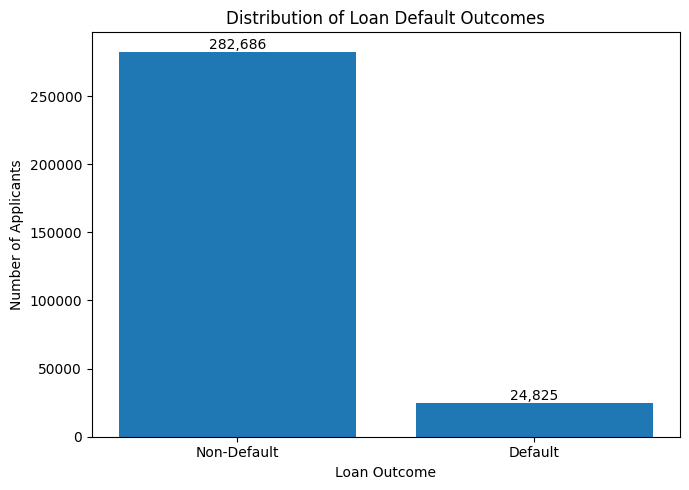

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

target_counts = application_train["TARGET"].value_counts().sort_index()

labels = ["Non-Default", "Default"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    target_counts.values
)

plt.title("Distribution of Loan Default Outcomes")
plt.ylabel("Number of Applicants")
plt.xlabel("Loan Outcome")

for bar, value in zip(bars, target_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

The dataset is highly imbalanced, with **282,686 applicants (91.93%) classified as non-default** and **24,825 applicants (8.07%) classified as default**. This shows that default cases represent a relatively small proportion of the overall applicant population. Therefore, a credit-risk prediction model should not rely on accuracy alone and must explicitly address **class imbalance** to identify high-risk applicants effectively.

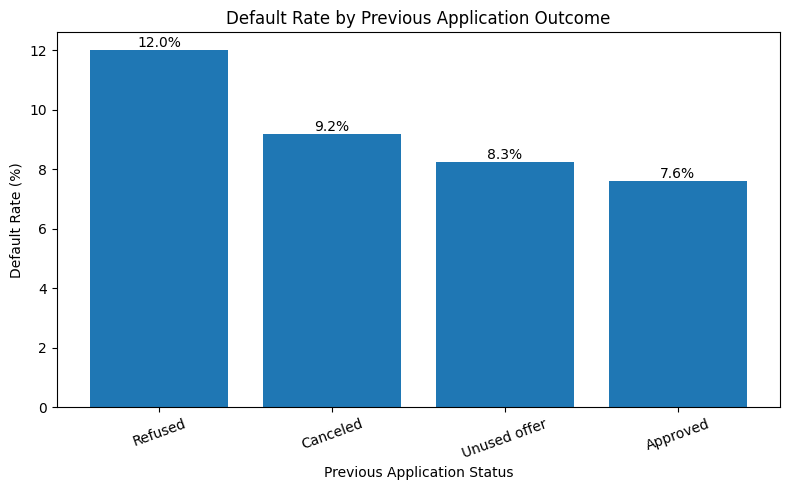

In [102]:
prev_status_rate = (
    prev_target
    .groupby("NAME_CONTRACT_STATUS")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    prev_status_rate.index,
    prev_status_rate.values * 100
)

plt.title("Default Rate by Previous Application Outcome")
plt.ylabel("Default Rate (%)")
plt.xlabel("Previous Application Status")
plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    prev_status_rate.values * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

Applicants whose previous loan applications were **refused have the highest observed default rate at 12.0%**, compared with **7.6% among applicants whose previous applications were approved**. This indicates that previous application outcomes contain useful information about future credit risk. Historical refusal behavior can therefore be incorporated into features such as **previous refusal count and refusal rate** when building the credit-risk model.

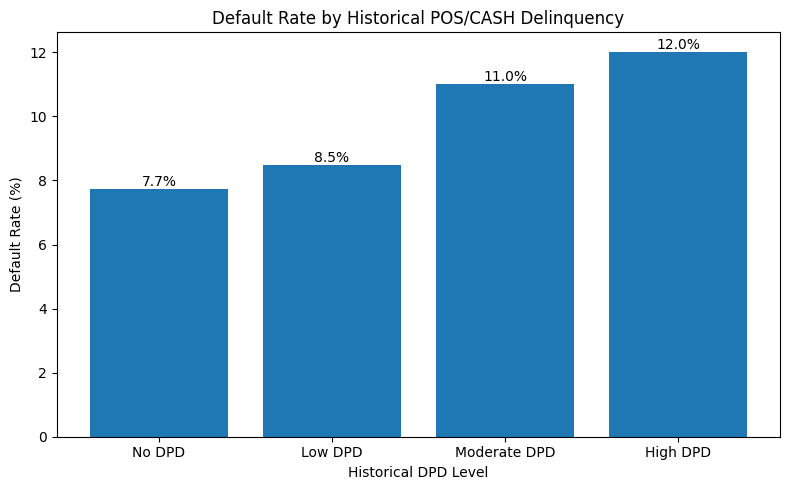

In [103]:
pos_dpd_rate = (
    pos_target
    .groupby("DPD_GROUP", observed=True)["TARGET"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    pos_dpd_rate.index.astype(str),
    pos_dpd_rate.values * 100
)

plt.title("Default Rate by Historical POS/CASH Delinquency")
plt.ylabel("Default Rate (%)")
plt.xlabel("Historical DPD Level")

for bar, value in zip(
    bars,
    pos_dpd_rate.values * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

The observed default rate increases with the severity of historical POS/CASH delinquency. Applicants with **no recorded DPD have a default rate of 7.7%**, while applicants in the **high-DPD group have a default rate of 12.0%**. This indicates that repeated or more severe payment delinquency in previous POS/CASH accounts is associated with increased credit risk. Features such as **DPD frequency, maximum DPD, and delinquency ratio** can therefore provide valuable signals for risk prediction.

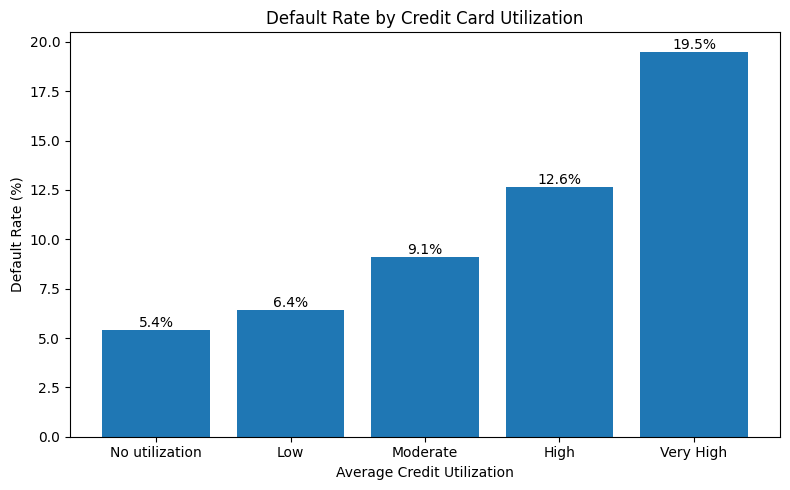

In [104]:
cc_util_rate = (
    cc_target
    .groupby("UTILIZATION_GROUP", observed=True)["TARGET"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cc_util_rate.index.astype(str),
    cc_util_rate.values * 100
)

plt.title("Default Rate by Credit Card Utilization")
plt.ylabel("Default Rate (%)")
plt.xlabel("Average Credit Utilization")

for bar, value in zip(
    bars,
    cc_util_rate.values * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

Credit-card utilization shows a strong relationship with observed default risk. The default rate increases from **5.4% for applicants with no utilization** to **19.5% for applicants with very high utilization**. This represents a substantial difference in observed risk and suggests that applicants using a large proportion of their available credit may have greater difficulty managing additional credit obligations. Therefore, **average and maximum credit-card utilization** are important behavioral features for the credit-risk model.

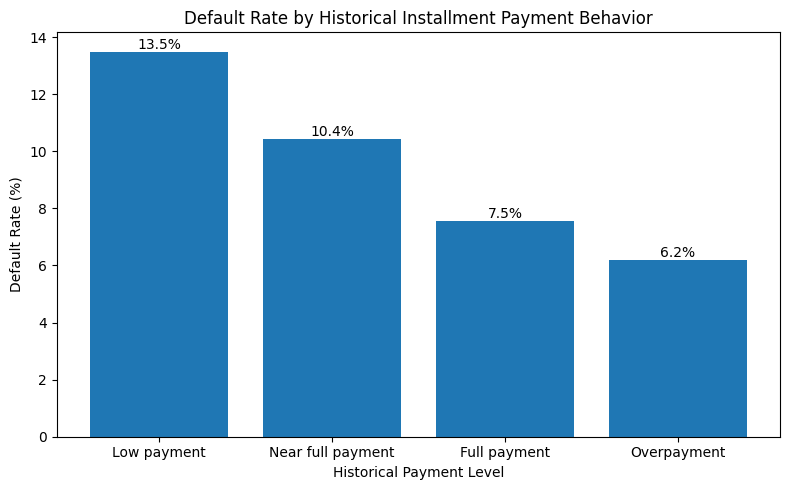

In [105]:
payment_rate = (
    inst_target
    .groupby("PAYMENT_GROUP", observed=True)["TARGET"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    payment_rate.index.astype(str),
    payment_rate.values * 100
)

plt.title("Default Rate by Historical Installment Payment Behavior")
plt.ylabel("Default Rate (%)")
plt.xlabel("Historical Payment Level")

for bar, value in zip(
    bars,
    payment_rate.values * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

Historical installment payment behavior shows a clear relationship with default risk. Applicants in the **low-payment group have the highest observed default rate at 13.5%**, while applicants making **full payments have a lower default rate of 7.5%**. This suggests that consistently paying a larger proportion of scheduled installment amounts is associated with lower credit risk. Features such as **overall payment ratio and underpayment ratio** can therefore help the model assess repayment reliability.

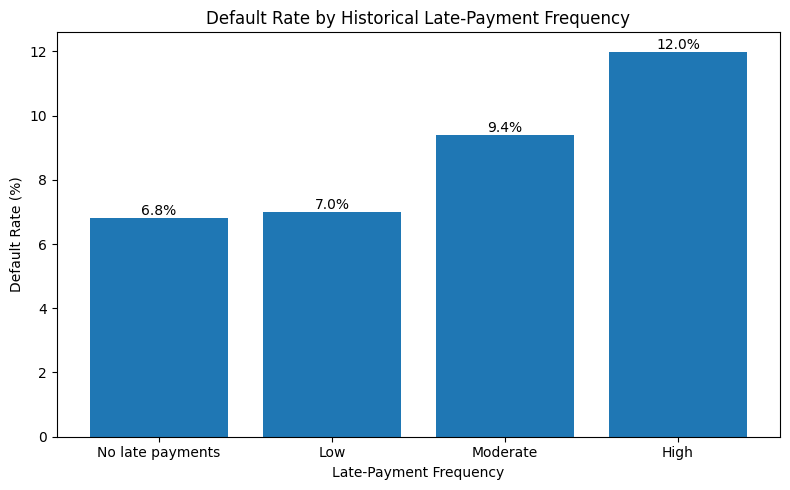

In [106]:
late_rate = (
    inst_target
    .groupby("LATE_GROUP", observed=True)["TARGET"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    late_rate.index.astype(str),
    late_rate.values * 100
)

plt.title("Default Rate by Historical Late-Payment Frequency")
plt.ylabel("Default Rate (%)")
plt.xlabel("Late-Payment Frequency")

for bar, value in zip(
    bars,
    late_rate.values * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Business Insight

The observed default rate generally increases as the frequency of historical late payments increases. Applicants with **no late payments have a default rate of 6.8%**, compared with **12.0% among applicants in the high late-payment group**. This indicates that repeated delays in historical installment payments are associated with increased future credit risk. Consequently, **late-payment count and late-payment ratio** are useful behavioral features for the credit-risk prediction model.

In [107]:
# ML SETUP — DATA VALIDATION

import numpy as np
import pandas as pd

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nMissing values:")
print("X:", X.isnull().sum().sum())
print("X_test:", X_test.isnull().sum().sum())

print("\nInfinite values:")
print(
    "X:",
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

print(
    "X_test:",
    np.isinf(X_test.select_dtypes(include=np.number)).sum().sum()
)

X shape: (307511, 231)
X_test shape: (48744, 231)
y shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0   91.9300
1    8.0700
Name: proportion, dtype: float64

Missing values:
X: 17506518
X_test: 2484452

Infinite values:
X: 0
X_test: 0


In [108]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print("Infinite values removed.")

Infinite values removed.


In [109]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numeric_cols))

Categorical features: 16
Numerical features: 215


In [110]:
for col in categorical_cols:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

In [111]:
constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("Constant columns:", len(constant_cols))

if constant_cols:
    print(constant_cols)

    X.drop(columns=constant_cols, inplace=True)
    X_test.drop(columns=constant_cols, inplace=True)

Constant columns: 0


In [112]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("\nFinal feature count:", X.shape[1])
print("Numerical:", len(numeric_cols))
print("Categorical:", len(categorical_cols))


Final feature count: 231
Numerical: 215
Categorical: 16


In [113]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nValidation target distribution:")
print(
    y_valid.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training set: (246008, 231)
Validation set: (61503, 231)

Training target distribution:
TARGET
0   91.9300
1    8.0700
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0   91.9300
1    8.0700
Name: proportion, dtype: float64


In [114]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}


In [115]:
import importlib.util

print("XGBoost:", importlib.util.find_spec("xgboost") is not None)
print("LightGBM:", importlib.util.find_spec("lightgbm") is not None)
print("CatBoost:", importlib.util.find_spec("catboost") is not None)

XGBoost: True
LightGBM: True
CatBoost: True


In [116]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

dummy = DummyClassifier(
    strategy="prior"
)

dummy.fit(X_train, y_train)

dummy_prob = dummy.predict_proba(X_valid)[:, 1]

print("Dummy ROC-AUC:",
      roc_auc_score(y_valid, dummy_prob))

print("Dummy PR-AUC:",
      average_precision_score(y_valid, dummy_prob))

Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.08072776937710356


In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [118]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight=class_weights,
                max_iter=1000,
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [119]:
import time

start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print(
    f"Training completed in {training_time:.2f} seconds"
)

Training completed in 326.15 seconds


In [120]:
logistic_valid_prob = logistic_model.predict_proba(
    X_valid
)[:, 1]

print(
    "First 10 predicted default probabilities:"
)

print(
    logistic_valid_prob[:10]
)

First 10 predicted default probabilities:
[0.25304501 0.33118229 0.77402644 0.39820542 0.59630467 0.59387938
 0.05503318 0.07131792 0.8000506  0.5057494 ]


In [121]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

logistic_roc_auc = roc_auc_score(
    y_valid,
    logistic_valid_prob
)

logistic_pr_auc = average_precision_score(
    y_valid,
    logistic_valid_prob
)

print(f"Logistic Regression ROC-AUC: {logistic_roc_auc:.4f}")
print(f"Logistic Regression PR-AUC : {logistic_pr_auc:.4f}")

Logistic Regression ROC-AUC: 0.7728
Logistic Regression PR-AUC : 0.2601


In [122]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

logistic_valid_pred = (
    logistic_valid_prob >= 0.5
).astype(int)

logistic_precision = precision_score(
    y_valid,
    logistic_valid_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_valid,
    logistic_valid_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_valid,
    logistic_valid_pred,
    zero_division=0
)

print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_valid,
        logistic_valid_pred
    )
)

Precision: 0.1746
Recall   : 0.6979
F1-score : 0.2793

Confusion Matrix:
[[40157 16381]
 [ 1500  3465]]


In [123]:
import xgboost as xgb
import numpy as np
import time

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [124]:
# Transform using the already-fitted Logistic Regression preprocessor
X_train_xgb = preprocessor.fit_transform(X_train)
X_valid_xgb = preprocessor.transform(X_valid)

print("Train shape:", X_train_xgb.shape)
print("Validation shape:", X_valid_xgb.shape)

Train shape: (246008, 361)
Validation shape: (61503, 361)


In [125]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 226148
Positive samples: 19860
scale_pos_weight: 11.38710976837865


In [128]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="auc",

    tree_method="hist",
    device="cuda",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=100
)

In [129]:
start_time = time.time()

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_valid_xgb, y_valid)],
    verbose=100
)

training_time = time.time() - start_time

print(f"\nXGBoost training completed in {training_time:.2f} seconds")
print(f"Best iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.69009
[100]	validation_0-auc:0.77688
[200]	validation_0-auc:0.78344
[300]	validation_0-auc:0.78524
[400]	validation_0-auc:0.78541
[437]	validation_0-auc:0.78531

XGBoost training completed in 9.72 seconds
Best iteration: 337


In [130]:
xgb_valid_prob = xgb_model.predict_proba(X_valid_xgb)[:, 1]

print("First 10 predicted default probabilities:")
print(xgb_valid_prob[:10])

First 10 predicted default probabilities:
[0.18935308 0.32211295 0.7393557  0.23728974 0.42496204 0.537423
 0.08551907 0.08488231 0.8213828  0.48499817]


In [131]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

xgb_roc_auc = roc_auc_score(y_valid, xgb_valid_prob)
xgb_pr_auc = average_precision_score(y_valid, xgb_valid_prob)

xgb_valid_pred = (xgb_valid_prob >= 0.5).astype(int)

xgb_precision = precision_score(y_valid, xgb_valid_pred)
xgb_recall = recall_score(y_valid, xgb_valid_pred)
xgb_f1 = f1_score(y_valid, xgb_valid_pred)

xgb_cm = confusion_matrix(y_valid, xgb_valid_pred)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")
print(f"XGBoost PR-AUC : {xgb_pr_auc:.4f}")
print(f"Precision      : {xgb_precision:.4f}")
print(f"Recall         : {xgb_recall:.4f}")
print(f"F1-score       : {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(xgb_cm)

XGBoost ROC-AUC: 0.7859
XGBoost PR-AUC : 0.2831
Precision      : 0.1985
Recall         : 0.6608
F1-score       : 0.3054

Confusion Matrix:
[[43294 13244]
 [ 1684  3281]]


#### Preliminary Model Benchmark:
Initial model experiments were conducted before finalizing the historical feature aggregation pipeline. These results are retained for comparison during development and are not treated as the final model results.

## Final Feature Engineering — Corrected Aggregations

The preliminary model experiments above were retained as development benchmarks. 
Before final model selection, historical transaction features are recomputed using 
exact sum-and-count aggregation rather than averaging chunk-level means. This ensures 
that applicant-level statistics are calculated consistently across the complete history.

In [133]:
# FINAL CORRECTED POS/CASH AGGREGATION

print("Loading POS/CASH data...")

pos_df = pd.read_csv(
    os.path.join(path, "POS_CASH_balance.csv")
)

print("POS/CASH shape:", pos_df.shape)

# Create indicators

pos_df["HAS_DPD"] = (
    pos_df["SK_DPD"] > 0
).astype("int8")

pos_df["HAS_DPD_DEF"] = (
    pos_df["SK_DPD_DEF"] > 0
).astype("int8")

pos_df["IS_ACTIVE"] = (
    pos_df["NAME_CONTRACT_STATUS"] == "Active"
).astype("int8")

pos_df["IS_COMPLETED"] = (
    pos_df["NAME_CONTRACT_STATUS"] == "Completed"
).astype("int8")


# Direct applicant-level aggregation

pos_features_corrected = (
    pos_df
    .groupby("SK_ID_CURR")
    .agg(
        # History
        POS_CONTRACT_COUNT=("SK_ID_PREV", "nunique"),
        POS_MONTH_COUNT=("MONTHS_BALANCE", "count"),

        # DPD
        POS_AVG_DPD=("SK_DPD", "mean"),
        POS_MAX_DPD=("SK_DPD", "max"),
        POS_DPD_MONTHS=("HAS_DPD", "sum"),

        # Default DPD
        POS_AVG_DPD_DEF=("SK_DPD_DEF", "mean"),
        POS_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
        POS_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum"),

        # Contract status
        POS_ACTIVE_COUNT=("IS_ACTIVE", "sum"),
        POS_COMPLETED_COUNT=("IS_COMPLETED", "sum"),

        # Installment behaviour
        POS_AVG_INSTALLMENTS=("CNT_INSTALMENT", "mean"),
        POS_AVG_FUTURE_INSTALLMENTS=(
            "CNT_INSTALMENT_FUTURE", "mean"
        ),

        POS_MIN_FUTURE_INSTALLMENTS=(
            "CNT_INSTALMENT_FUTURE", "min"
        )
    )
    .reset_index()
)


# Ratios

pos_features_corrected["POS_DPD_RATIO"] = (
    pos_features_corrected["POS_DPD_MONTHS"] /
    pos_features_corrected["POS_MONTH_COUNT"]
)

pos_features_corrected["POS_DPD_DEF_RATIO"] = (
    pos_features_corrected["POS_DPD_DEF_MONTHS"] /
    pos_features_corrected["POS_MONTH_COUNT"]
)

pos_features_corrected["POS_ACTIVE_RATIO"] = (
    pos_features_corrected["POS_ACTIVE_COUNT"] /
    pos_features_corrected["POS_MONTH_COUNT"]
)


# Clean infinite values

pos_features_corrected.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# Verification

print("\nCorrected POS/CASH shape:")
print(pos_features_corrected.shape)

print("\nUnique applicants:",
      pos_features_corrected["SK_ID_CURR"].nunique())

print("Duplicate applicant IDs:",
      pos_features_corrected["SK_ID_CURR"].duplicated().sum())

print("\nCorrected columns:")
print(pos_features_corrected.columns.tolist())

display(pos_features_corrected.head())

Loading POS/CASH data...
POS/CASH shape: (10001358, 8)

Corrected POS/CASH shape:
(337252, 17)

Unique applicants: 337252
Duplicate applicant IDs: 0

Corrected columns:
['SK_ID_CURR', 'POS_CONTRACT_COUNT', 'POS_MONTH_COUNT', 'POS_AVG_DPD', 'POS_MAX_DPD', 'POS_DPD_MONTHS', 'POS_AVG_DPD_DEF', 'POS_MAX_DPD_DEF', 'POS_DPD_DEF_MONTHS', 'POS_ACTIVE_COUNT', 'POS_COMPLETED_COUNT', 'POS_AVG_INSTALLMENTS', 'POS_AVG_FUTURE_INSTALLMENTS', 'POS_MIN_FUTURE_INSTALLMENTS', 'POS_DPD_RATIO', 'POS_DPD_DEF_RATIO', 'POS_ACTIVE_RATIO']


,SK_ID_CURR,POS_CONTRACT_COUNT,POS_MONTH_COUNT,POS_AVG_DPD,POS_MAX_DPD,POS_DPD_MONTHS,POS_AVG_DPD_DEF,POS_MAX_DPD_DEF,POS_DPD_DEF_MONTHS,POS_ACTIVE_COUNT,POS_COMPLETED_COUNT,POS_AVG_INSTALLMENTS,POS_AVG_FUTURE_INSTALLMENTS,POS_MIN_FUTURE_INSTALLMENTS,POS_DPD_RATIO,POS_DPD_DEF_RATIO,POS_ACTIVE_RATIO
0,100001,2,9,0.7778,7,1,0.7778,7,1,7,2,4.0000,1.4444,0.0000,0.1111,0.1111,0.7778
1,100002,1,19,0.0000,0,0,0.0000,0,0,19,0,24.0000,15.0000,6.0000,0.0000,0.0000,1.0000
2,100003,3,28,0.0000,0,0,0.0000,0,0,26,2,10.1071,5.7857,0.0000,0.0000,0.0000,0.9286
3,100004,1,4,0.0000,0,0,0.0000,0,0,3,1,3.7500,2.2500,0.0000,0.0000,0.0000,0.7500
4,100005,1,11,0.0000,0,0,0.0000,0,0,9,1,11.7000,7.2000,0.0000,0.0000,0.0000,0.8182


In [134]:
# FINAL CORRECTED CREDIT CARD AGGREGATION

print("Loading Credit Card data...")

cc_df = pd.read_csv(
    os.path.join(path, "credit_card_balance.csv")
)

print("Credit Card shape:", cc_df.shape)

# Create utilization

cc_df["UTILIZATION"] = np.where(
    cc_df["AMT_CREDIT_LIMIT_ACTUAL"] > 0,
    cc_df["AMT_BALANCE"] /
    cc_df["AMT_CREDIT_LIMIT_ACTUAL"],
    np.nan
)

# Indicators

cc_df["HAS_DPD"] = (
    cc_df["SK_DPD"] > 0
).astype("int8")

cc_df["HAS_DPD_DEF"] = (
    cc_df["SK_DPD_DEF"] > 0
).astype("int8")

cc_df["HAS_PAYMENT"] = (
    cc_df["AMT_PAYMENT_CURRENT"].notna()
).astype("int8")


# Direct applicant-level aggregation

cc_features_corrected = (
    cc_df
    .groupby("SK_ID_CURR")
    .agg(
        # History
        CC_CONTRACT_COUNT=("SK_ID_PREV", "nunique"),
        CC_MONTH_COUNT=("MONTHS_BALANCE", "count"),

        # Balance
        CC_AVG_BALANCE=("AMT_BALANCE", "mean"),
        CC_MAX_BALANCE=("AMT_BALANCE", "max"),

        # Credit limit
        CC_AVG_CREDIT_LIMIT=(
            "AMT_CREDIT_LIMIT_ACTUAL", "mean"
        ),
        CC_MAX_CREDIT_LIMIT=(
            "AMT_CREDIT_LIMIT_ACTUAL", "max"
        ),

        # Utilization
        CC_AVG_UTILIZATION=("UTILIZATION", "mean"),
        CC_MAX_UTILIZATION=("UTILIZATION", "max"),

        # Drawings
        CC_TOTAL_DRAWINGS=("AMT_DRAWINGS_CURRENT", "sum"),
        CC_AVG_DRAWINGS=("AMT_DRAWINGS_CURRENT", "mean"),
        CC_TOTAL_DRAWING_COUNT=(
            "CNT_DRAWINGS_CURRENT", "sum"
        ),

        # Payments
        CC_TOTAL_PAYMENT=(
            "AMT_PAYMENT_CURRENT", "sum"
        ),
        CC_AVG_PAYMENT=(
            "AMT_PAYMENT_CURRENT", "mean"
        ),
        CC_PAYMENT_MONTHS=("HAS_PAYMENT", "sum"),

        # Minimum payment
        CC_AVG_MIN_PAYMENT=(
            "AMT_INST_MIN_REGULARITY", "mean"
        ),

        # Installments
        CC_MAX_MATURE_INSTALLMENTS=(
            "CNT_INSTALMENT_MATURE_CUM", "max"
        ),

        # DPD
        CC_AVG_DPD=("SK_DPD", "mean"),
        CC_MAX_DPD=("SK_DPD", "max"),
        CC_DPD_MONTHS=("HAS_DPD", "sum"),

        # DPD default
        CC_AVG_DPD_DEF=("SK_DPD_DEF", "mean"),
        CC_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
        CC_DPD_DEF_MONTHS=("HAS_DPD_DEF", "sum")
    )
    .reset_index()
)


# Ratios

cc_features_corrected["CC_DPD_RATIO"] = (
    cc_features_corrected["CC_DPD_MONTHS"] /
    cc_features_corrected["CC_MONTH_COUNT"]
)

cc_features_corrected["CC_DPD_DEF_RATIO"] = (
    cc_features_corrected["CC_DPD_DEF_MONTHS"] /
    cc_features_corrected["CC_MONTH_COUNT"]
)

cc_features_corrected["CC_PAYMENT_MONTH_RATIO"] = (
    cc_features_corrected["CC_PAYMENT_MONTHS"] /
    cc_features_corrected["CC_MONTH_COUNT"]
)

# Payment-to-minimum-payment ratio

cc_features_corrected["CC_PAYMENT_TO_MIN_RATIO"] = (
    cc_features_corrected["CC_TOTAL_PAYMENT"] /
    cc_features_corrected["CC_AVG_MIN_PAYMENT"]
)


# Clean infinite values

cc_features_corrected.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# Verification

print("\nCorrected Credit Card shape:")
print(cc_features_corrected.shape)

print(
    "\nUnique applicants:",
    cc_features_corrected["SK_ID_CURR"].nunique()
)

print(
    "Duplicate applicant IDs:",
    cc_features_corrected["SK_ID_CURR"].duplicated().sum()
)

print("\nCorrected columns:")
print(cc_features_corrected.columns.tolist())

display(cc_features_corrected.head())

Loading Credit Card data...
Credit Card shape: (3840312, 23)

Corrected Credit Card shape:
(103558, 27)

Unique applicants: 103558
Duplicate applicant IDs: 0

Corrected columns:
['SK_ID_CURR', 'CC_CONTRACT_COUNT', 'CC_MONTH_COUNT', 'CC_AVG_BALANCE', 'CC_MAX_BALANCE', 'CC_AVG_CREDIT_LIMIT', 'CC_MAX_CREDIT_LIMIT', 'CC_AVG_UTILIZATION', 'CC_MAX_UTILIZATION', 'CC_TOTAL_DRAWINGS', 'CC_AVG_DRAWINGS', 'CC_TOTAL_DRAWING_COUNT', 'CC_TOTAL_PAYMENT', 'CC_AVG_PAYMENT', 'CC_PAYMENT_MONTHS', 'CC_AVG_MIN_PAYMENT', 'CC_MAX_MATURE_INSTALLMENTS', 'CC_AVG_DPD', 'CC_MAX_DPD', 'CC_DPD_MONTHS', 'CC_AVG_DPD_DEF', 'CC_MAX_DPD_DEF', 'CC_DPD_DEF_MONTHS', 'CC_DPD_RATIO', 'CC_DPD_DEF_RATIO', 'CC_PAYMENT_MONTH_RATIO', 'CC_PAYMENT_TO_MIN_RATIO']


,SK_ID_CURR,CC_CONTRACT_COUNT,CC_MONTH_COUNT,CC_AVG_BALANCE,CC_MAX_BALANCE,CC_AVG_CREDIT_LIMIT,CC_MAX_CREDIT_LIMIT,CC_AVG_UTILIZATION,CC_MAX_UTILIZATION,CC_TOTAL_DRAWINGS,CC_AVG_DRAWINGS,CC_TOTAL_DRAWING_COUNT,CC_TOTAL_PAYMENT,CC_AVG_PAYMENT,CC_PAYMENT_MONTHS,CC_AVG_MIN_PAYMENT,CC_MAX_MATURE_INSTALLMENTS,CC_AVG_DPD,CC_MAX_DPD,CC_DPD_MONTHS,CC_AVG_DPD_DEF,CC_MAX_DPD_DEF,CC_DPD_DEF_MONTHS,CC_DPD_RATIO,CC_DPD_DEF_RATIO,CC_PAYMENT_MONTH_RATIO,CC_PAYMENT_TO_MIN_RATIO
0,100006,1,6,0.0000,0.0000,270000.0000,270000,0.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN
1,100011,1,74,54482.1111,189000.0000,164189.1892,180000,0.3027,1.0500,180000.0000,2432.4324,4,358386.7500,4843.0642,74,3956.2218,33.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,1.0000,90.5881
2,100013,1,96,18159.9192,161420.2200,131718.7500,157500,0.1153,1.0249,571500.0000,5953.1250,23,688161.2400,7168.3462,96,1454.5396,22.0000,0.0104,1,1,0.0104,1,1,0.0104,0.0104,1.0000,473.1128
3,100021,1,17,0.0000,0.0000,675000.0000,675000,0.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN
4,100023,1,8,0.0000,0.0000,135000.0000,225000,0.0000,0.0000,0.0000,0.0000,0,0.0000,NaN,0,0.0000,0.0000,0.0000,0,0,0.0000,0,0,0.0000,0.0000,0.0000,NaN


In [135]:
# FINAL CORRECTED INSTALLMENTS AGGREGATION

print("Loading Installments Payments data...")

inst_df = pd.read_csv(
    os.path.join(path, "installments_payments.csv")
)

print("Installments shape:", inst_df.shape)


# Create payment behaviour variables

# Payment delay:
# Positive = payment was made after scheduled date
inst_df["PAYMENT_DELAY"] = (
    inst_df["DAYS_ENTRY_PAYMENT"] -
    inst_df["DAYS_INSTALMENT"]
)

inst_df["IS_LATE"] = (
    inst_df["PAYMENT_DELAY"] > 0
).astype("int8")


# Payment ratio
inst_df["PAYMENT_RATIO"] = np.where(
    inst_df["AMT_INSTALMENT"] > 0,
    inst_df["AMT_PAYMENT"] /
    inst_df["AMT_INSTALMENT"],
    np.nan
)


# Underpayment
inst_df["IS_UNDERPAID"] = np.where(
    inst_df["AMT_PAYMENT"].notna() &
    inst_df["AMT_INSTALMENT"].notna(),
    (
        inst_df["AMT_PAYMENT"] <
        inst_df["AMT_INSTALMENT"]
    ).astype("int8"),
    np.nan
)


# Direct applicant-level aggregation

inst_features_corrected = (
    inst_df
    .groupby("SK_ID_CURR")
    .agg(

        # Number of installment records
        INSTALLMENT_COUNT=(
            "SK_ID_PREV",
            "count"
        ),

        # Payment timing
        AVG_PAYMENT_DELAY=(
            "PAYMENT_DELAY",
            "mean"
        ),

        MAX_PAYMENT_DELAY=(
            "PAYMENT_DELAY",
            "max"
        ),

        LATE_PAYMENT_COUNT=(
            "IS_LATE",
            "sum"
        ),

        # Underpayment
        UNDERPAYMENT_COUNT=(
            "IS_UNDERPAID",
            "sum"
        ),

        # Payment ratio
        AVG_PAYMENT_RATIO=(
            "PAYMENT_RATIO",
            "mean"
        ),

        # Amounts
        TOTAL_INSTALLMENT_AMOUNT=(
            "AMT_INSTALMENT",
            "sum"
        ),

        TOTAL_PAYMENT_AMOUNT=(
            "AMT_PAYMENT",
            "sum"
        ),

        AVG_INSTALLMENT_AMOUNT=(
            "AMT_INSTALMENT",
            "mean"
        ),

        AVG_PAYMENT_AMOUNT=(
            "AMT_PAYMENT",
            "mean"
        ),

        # Behaviour ratios
        LATE_PAYMENT_RATIO=(
            "IS_LATE",
            "mean"
        ),

        UNDERPAYMENT_RATIO=(
            "IS_UNDERPAID",
            "mean"
        )
    )
    .reset_index()
)


# Overall payment ratio

inst_features_corrected["OVERALL_PAYMENT_RATIO"] = np.where(
    inst_features_corrected["TOTAL_INSTALLMENT_AMOUNT"] > 0,
    inst_features_corrected["TOTAL_PAYMENT_AMOUNT"] /
    inst_features_corrected["TOTAL_INSTALLMENT_AMOUNT"],
    np.nan
)


# Clean infinite values

inst_features_corrected.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# Verification

print("\nCorrected Installments shape:")
print(inst_features_corrected.shape)

print(
    "\nUnique applicants:",
    inst_features_corrected["SK_ID_CURR"].nunique()
)

print(
    "Duplicate applicant IDs:",
    inst_features_corrected["SK_ID_CURR"].duplicated().sum()
)

print("\nCorrected columns:")
print(inst_features_corrected.columns.tolist())

display(inst_features_corrected.head())

Loading Installments Payments data...
Installments shape: (13605401, 8)

Corrected Installments shape:
(339587, 14)

Unique applicants: 339587
Duplicate applicant IDs: 0

Corrected columns:
['SK_ID_CURR', 'INSTALLMENT_COUNT', 'AVG_PAYMENT_DELAY', 'MAX_PAYMENT_DELAY', 'LATE_PAYMENT_COUNT', 'UNDERPAYMENT_COUNT', 'AVG_PAYMENT_RATIO', 'TOTAL_INSTALLMENT_AMOUNT', 'TOTAL_PAYMENT_AMOUNT', 'AVG_INSTALLMENT_AMOUNT', 'AVG_PAYMENT_AMOUNT', 'LATE_PAYMENT_RATIO', 'UNDERPAYMENT_RATIO', 'OVERALL_PAYMENT_RATIO']


,SK_ID_CURR,INSTALLMENT_COUNT,AVG_PAYMENT_DELAY,MAX_PAYMENT_DELAY,LATE_PAYMENT_COUNT,UNDERPAYMENT_COUNT,AVG_PAYMENT_RATIO,TOTAL_INSTALLMENT_AMOUNT,TOTAL_PAYMENT_AMOUNT,AVG_INSTALLMENT_AMOUNT,AVG_PAYMENT_AMOUNT,LATE_PAYMENT_RATIO,UNDERPAYMENT_RATIO,OVERALL_PAYMENT_RATIO
0,100001,7,-7.2857,11.0000,1,0.0000,1.0000,41195.9250,41195.9250,5885.1321,5885.1321,0.1429,0.0000,1.0000
1,100002,19,-20.4211,-12.0000,0,0.0000,1.0000,219625.6950,219625.6950,11559.2471,11559.2471,0.0000,0.0000,1.0000
2,100003,25,-7.1600,-1.0000,0,0.0000,1.0000,1618864.6500,1618864.6500,64754.5860,64754.5860,0.0000,0.0000,1.0000
3,100004,3,-7.6667,-3.0000,0,0.0000,1.0000,21288.4650,21288.4650,7096.1550,7096.1550,0.0000,0.0000,1.0000
4,100005,9,-23.5556,1.0000,1,0.0000,1.0000,56161.8450,56161.8450,6240.2050,6240.2050,0.1111,0.0000,1.0000


In [136]:
# FREE MEMORY FROM RAW HISTORICAL DATA

del pos_df
del cc_df
del inst_df

import gc
gc.collect()

print("Raw historical DataFrames removed from memory.")
print("Corrected feature tables retained:")
print("POS:", pos_features_corrected.shape)
print("CC :", cc_features_corrected.shape)
print("INST:", inst_features_corrected.shape)

Raw historical DataFrames removed from memory.
Corrected feature tables retained:
POS: (337252, 17)
CC : (103558, 27)
INST: (339587, 14)


In [137]:
# FINAL CORRECTED DATASET MERGE

print("Rebuilding final train/test datasets...")

# Start from the original application-level data
train_final = application_train.copy()
test_final = application_test.copy()

# Merge Bureau features

train_final = train_final.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)


# Merge Bureau Balance features

train_final = train_final.merge(
    bureau_balance_applicant,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    bureau_balance_applicant,
    on="SK_ID_CURR",
    how="left"
)


# Merge Previous Application features

train_final = train_final.merge(
    previous_features,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    previous_features,
    on="SK_ID_CURR",
    how="left"
)


# IMPORTANT:
# Use CORRECTED POS/CASH features

train_final = train_final.merge(
    pos_features_corrected,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    pos_features_corrected,
    on="SK_ID_CURR",
    how="left"
)


# Use CORRECTED Credit Card features

train_final = train_final.merge(
    cc_features_corrected,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    cc_features_corrected,
    on="SK_ID_CURR",
    how="left"
)


# Use CORRECTED Installment features

train_final = train_final.merge(
    inst_features_corrected,
    on="SK_ID_CURR",
    how="left"
)

test_final = test_final.merge(
    inst_features_corrected,
    on="SK_ID_CURR",
    how="left"
)


# VALIDATION CHECKS

print("\nFinal train shape:", train_final.shape)
print("Final test shape :", test_final.shape)

print(
    "\nTrain unique applicants:",
    train_final["SK_ID_CURR"].nunique()
)

print(
    "Test unique applicants:",
    test_final["SK_ID_CURR"].nunique()
)

print(
    "\nTrain duplicate IDs:",
    train_final["SK_ID_CURR"].duplicated().sum()
)

print(
    "Test duplicate IDs:",
    test_final["SK_ID_CURR"].duplicated().sum()
)

print(
    "\nTARGET present in train:",
    "TARGET" in train_final.columns
)

print(
    "TARGET present in test:",
    "TARGET" in test_final.columns
)

print("\nFinal train columns:", train_final.shape[1])
print("Final test columns :", test_final.shape[1])

Rebuilding final train/test datasets...

Final train shape: (307511, 216)
Final test shape : (48744, 215)

Train unique applicants: 307511
Test unique applicants: 48744

Train duplicate IDs: 0
Test duplicate IDs: 0

TARGET present in train: True
TARGET present in test: False

Final train columns: 216
Final test columns : 215


In [138]:
# FINAL FEATURE ENGINEERING

import numpy as np
import pandas as pd

print("Starting final feature engineering...")


# Separate target

X = train_final.drop(columns=["TARGET"]).copy()
y = train_final["TARGET"].copy()

X_test = test_final.copy()

# Keep test IDs for final predictions
test_ids = X_test["SK_ID_CURR"].copy()



# Financial ratios

X["CREDIT_INCOME_RATIO"] = (
    X["AMT_CREDIT"] / X["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

X_test["CREDIT_INCOME_RATIO"] = (
    X_test["AMT_CREDIT"] / X_test["AMT_INCOME_TOTAL"].replace(0, np.nan)
)


X["ANNUITY_INCOME_RATIO"] = (
    X["AMT_ANNUITY"] / X["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

X_test["ANNUITY_INCOME_RATIO"] = (
    X_test["AMT_ANNUITY"] / X_test["AMT_INCOME_TOTAL"].replace(0, np.nan)
)


X["GOODS_INCOME_RATIO"] = (
    X["AMT_GOODS_PRICE"] / X["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

X_test["GOODS_INCOME_RATIO"] = (
    X_test["AMT_GOODS_PRICE"] / X_test["AMT_INCOME_TOTAL"].replace(0, np.nan)
)


X["ANNUITY_CREDIT_RATIO"] = (
    X["AMT_ANNUITY"] / X["AMT_CREDIT"].replace(0, np.nan)
)

X_test["ANNUITY_CREDIT_RATIO"] = (
    X_test["AMT_ANNUITY"] / X_test["AMT_CREDIT"].replace(0, np.nan)
)


X["CREDIT_GOODS_RATIO"] = (
    X["AMT_CREDIT"] / X["AMT_GOODS_PRICE"].replace(0, np.nan)
)

X_test["CREDIT_GOODS_RATIO"] = (
    X_test["AMT_CREDIT"] / X_test["AMT_GOODS_PRICE"].replace(0, np.nan)
)


# Age and employment

# Home Credit stores age as negative days
X["AGE_YEARS"] = (-X["DAYS_BIRTH"]) / 365.25
X_test["AGE_YEARS"] = (-X_test["DAYS_BIRTH"]) / 365.25


# 365243 is a special placeholder value in Home Credit
X["DAYS_EMPLOYED"] = X["DAYS_EMPLOYED"].replace(365243, np.nan)
X_test["DAYS_EMPLOYED"] = X_test["DAYS_EMPLOYED"].replace(365243, np.nan)

X["EMPLOYMENT_YEARS"] = (-X["DAYS_EMPLOYED"]) / 365.25
X_test["EMPLOYMENT_YEARS"] = (-X_test["DAYS_EMPLOYED"]) / 365.25


# Family / income features

X["INCOME_PER_FAMILY_MEMBER"] = (
    X["AMT_INCOME_TOTAL"] /
    X["CNT_FAM_MEMBERS"].replace(0, np.nan)
)

X_test["INCOME_PER_FAMILY_MEMBER"] = (
    X_test["AMT_INCOME_TOTAL"] /
    X_test["CNT_FAM_MEMBERS"].replace(0, np.nan)
)


X["INCOME_PER_CHILD"] = (
    X["AMT_INCOME_TOTAL"] /
    (X["CNT_CHILDREN"] + 1)
)

X_test["INCOME_PER_CHILD"] = (
    X_test["AMT_INCOME_TOTAL"] /
    (X_test["CNT_CHILDREN"] + 1)
)


# Document count

doc_cols = [
    col for col in X.columns
    if col.startswith("FLAG_DOCUMENT_")
]

X["DOCUMENTS_PROVIDED_COUNT"] = X[doc_cols].sum(axis=1)
X_test["DOCUMENTS_PROVIDED_COUNT"] = X_test[doc_cols].sum(axis=1)


# Historical data availability flags

X["HAS_CC_HISTORY"] = X["CC_CONTRACT_COUNT"].notna().astype("int8")
X_test["HAS_CC_HISTORY"] = X_test["CC_CONTRACT_COUNT"].notna().astype("int8")


X["HAS_BUREAU_HISTORY"] = X["BUREAU_CREDIT_COUNT"].notna().astype("int8")
X_test["HAS_BUREAU_HISTORY"] = X_test["BUREAU_CREDIT_COUNT"].notna().astype("int8")


X["HAS_PREVIOUS_APPLICATION"] = X["PREV_APP_COUNT"].notna().astype("int8")
X_test["HAS_PREVIOUS_APPLICATION"] = X_test["PREV_APP_COUNT"].notna().astype("int8")


X["HAS_POS_HISTORY"] = X["POS_CONTRACT_COUNT"].notna().astype("int8")
X_test["HAS_POS_HISTORY"] = X_test["POS_CONTRACT_COUNT"].notna().astype("int8")


X["HAS_INSTALLMENT_HISTORY"] = X["INSTALLMENT_COUNT"].notna().astype("int8")
X_test["HAS_INSTALLMENT_HISTORY"] = X_test["INSTALLMENT_COUNT"].notna().astype("int8")


# ------------------------------------------------------------
# Bureau risk ratios
# ------------------------------------------------------------

X["BUREAU_DEBT_CREDIT_RATIO"] = (
    X["BUREAU_TOTAL_DEBT"] /
    X["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
)

X_test["BUREAU_DEBT_CREDIT_RATIO"] = (
    X_test["BUREAU_TOTAL_DEBT"] /
    X_test["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
)


X["BUREAU_OVERDUE_CREDIT_RATIO"] = (
    X["BUREAU_TOTAL_OVERDUE"] /
    X["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
)

X_test["BUREAU_OVERDUE_CREDIT_RATIO"] = (
    X_test["BUREAU_TOTAL_OVERDUE"] /
    X_test["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
)


# Replace infinite values

X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)


# Handle categorical columns

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

for col in categorical_cols:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)


# Remove constant columns

constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

if constant_cols:
    X = X.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)

    categorical_cols = [
        col for col in categorical_cols
        if col not in constant_cols
    ]

    numeric_cols = [
        col for col in numeric_cols
        if col not in constant_cols
    ]


# Remove applicant ID from ML features

X = X.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])


# Recalculate feature lists
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]


# SUMMARY

print("\nFINAL FEATURE ENGINEERING COMPLETE")
print("-----------------------------------")
print("X shape      :", X.shape)
print("X_test shape :", X_test.shape)
print("Target shape :", y.shape)

print("\nNumerical features :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))
print("Constant columns removed:", len(constant_cols))

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Starting final feature engineering...

FINAL FEATURE ENGINEERING COMPLETE
-----------------------------------
X shape      : (307511, 231)
X_test shape : (48744, 231)
Target shape : (307511,)

Numerical features : 215
Categorical features: 16
Constant columns removed: 0

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target proportions:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


In [139]:
# FINAL TRAIN / VALIDATION SPLIT

from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_valid.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts())
print(y_valid.value_counts(normalize=True))


# CLASS WEIGHTS

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

class_weights = {
    0: 1.0,
    1: scale_pos_weight
}

print("\nClass weights:", class_weights)
print("scale_pos_weight:", scale_pos_weight)

Train shape     : (246008, 231)
Validation shape: (61503, 231)

Train target distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    56538
1     4965
Name: count, dtype: int64
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

Class weights: {0: 1.0, 1: np.float64(11.38710976837865)}
scale_pos_weight: 11.38710976837865


In [140]:
# FINAL PREPROCESSING PIPELINE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical features

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])


# Combined preprocessing

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


# FIT ONLY ON TRAINING DATA

print("Fitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("\nPreprocessing complete.")
print("Processed train shape :", X_train_processed.shape)
print("Processed valid shape :", X_valid_processed.shape)

print("\nProcessed data type:")
print(type(X_train_processed))

print("\nNumber of processed features:",
      X_train_processed.shape[1])

Fitting preprocessing pipeline...

Preprocessing complete.
Processed train shape : (246008, 361)
Processed valid shape : (61503, 361)

Processed data type:
<class 'numpy.ndarray'>

Number of processed features: 361


In [141]:
# FINAL MODEL 1 — LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import time

print("Training Logistic Regression...")

start_time = time.time()

logistic_model = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

training_time = time.time() - start_time

# Validation predictions

y_valid_prob_lr = logistic_model.predict_proba(
    X_valid_processed
)[:, 1]

y_valid_pred_lr = (
    y_valid_prob_lr >= 0.5
).astype(int)


# Evaluation

lr_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_lr
)

lr_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_lr
)

lr_precision = precision_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
)

lr_cm = confusion_matrix(
    y_valid,
    y_valid_pred_lr
)


# RESULTS

print("\n" + "=" * 55)
print("LOGISTIC REGRESSION — FINAL BASELINE")
print("=" * 55)

print(f"Training time : {training_time:.2f} seconds")
print(f"ROC-AUC       : {lr_roc_auc:.4f}")
print(f"PR-AUC        : {lr_pr_auc:.4f}")
print(f"Precision     : {lr_precision:.4f}")
print(f"Recall        : {lr_recall:.4f}")
print(f"F1 Score      : {lr_f1:.4f}")

print("\nConfusion Matrix:")
print(lr_cm)

Training Logistic Regression...

LOGISTIC REGRESSION — FINAL BASELINE
Training time : 354.40 seconds
ROC-AUC       : 0.7735
PR-AUC        : 0.2608
Precision     : 0.1749
Recall        : 0.6975
F1 Score      : 0.2797

Confusion Matrix:
[[40204 16334]
 [ 1502  3463]]


In [142]:
# FINAL MODEL 2 — XGBOOST

import xgboost as xgb
import time

print("Training XGBoost...")

start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    # Handle class imbalance
    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="auc",

    tree_method="hist",
    device="cuda",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=100
)

xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_valid_processed, y_valid)],
    verbose=100
)

training_time_xgb = time.time() - start_time


# VALIDATION PREDICTIONS

y_valid_prob_xgb = xgb_model.predict_proba(
    X_valid_processed
)[:, 1]

y_valid_pred_xgb = (
    y_valid_prob_xgb >= 0.5
).astype(int)


# EVALUATION

xgb_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_xgb
)

xgb_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_xgb
)

xgb_precision = precision_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_valid,
    y_valid_pred_xgb,
    zero_division=0
)

xgb_cm = confusion_matrix(
    y_valid,
    y_valid_pred_xgb
)


# RESULTS

print("\n" + "=" * 55)
print("XGBOOST — FINAL MODEL")
print("=" * 55)

print(f"Training time : {training_time_xgb:.2f} seconds")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"ROC-AUC       : {xgb_roc_auc:.4f}")
print(f"PR-AUC        : {xgb_pr_auc:.4f}")
print(f"Precision     : {xgb_precision:.4f}")
print(f"Recall        : {xgb_recall:.4f}")
print(f"F1 Score      : {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(xgb_cm)

Training XGBoost...
[0]	validation_0-auc:0.69048
[100]	validation_0-auc:0.77734
[200]	validation_0-auc:0.78399
[300]	validation_0-auc:0.78622
[400]	validation_0-auc:0.78696
[500]	validation_0-auc:0.78732
[583]	validation_0-auc:0.78690

XGBOOST — FINAL MODEL
Training time : 11.09 seconds
Best iteration: 483
ROC-AUC       : 0.7874
PR-AUC        : 0.2848
Precision     : 0.2045
Recall        : 0.6455
F1 Score      : 0.3107

Confusion Matrix:
[[44074 12464]
 [ 1760  3205]]


In [143]:
# FINAL MODEL 3 — LIGHTGBM

import lightgbm as lgb
import time

print("Training LightGBM...")

start_time = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary",
    metric="auc",

    random_state=42,
    n_jobs=-1,

    verbosity=-1
)

lgbm_model.fit(
    X_train_processed,
    y_train,

    eval_set=[(X_valid_processed, y_valid)],

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

training_time_lgbm = time.time() - start_time


# VALIDATION PREDICTIONS

y_valid_prob_lgbm = lgbm_model.predict_proba(
    X_valid_processed
)[:, 1]

y_valid_pred_lgbm = (
    y_valid_prob_lgbm >= 0.5
).astype(int)


# EVALUATION

lgbm_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_lgbm
)

lgbm_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_lgbm
)

lgbm_precision = precision_score(
    y_valid,
    y_valid_pred_lgbm,
    zero_division=0
)

lgbm_recall = recall_score(
    y_valid,
    y_valid_pred_lgbm,
    zero_division=0
)

lgbm_f1 = f1_score(
    y_valid,
    y_valid_pred_lgbm,
    zero_division=0
)

lgbm_cm = confusion_matrix(
    y_valid,
    y_valid_pred_lgbm
)


# RESULTS

print("\n" + "=" * 55)
print("LIGHTGBM — FINAL MODEL")
print("=" * 55)

print(f"Training time : {training_time_lgbm:.2f} seconds")
print(f"Best iteration: {lgbm_model.best_iteration_}")
print(f"ROC-AUC       : {lgbm_roc_auc:.4f}")
print(f"PR-AUC        : {lgbm_pr_auc:.4f}")
print(f"Precision     : {lgbm_precision:.4f}")
print(f"Recall        : {lgbm_recall:.4f}")
print(f"F1 Score      : {lgbm_f1:.4f}")

print("\nConfusion Matrix:")
print(lgbm_cm)

Training LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[429]	valid_0's auc: 0.786998

LIGHTGBM — FINAL MODEL
Training time : 33.44 seconds
Best iteration: 429
ROC-AUC       : 0.7870
PR-AUC        : 0.2844
Precision     : 0.1930
Recall        : 0.6806
F1 Score      : 0.3008

Confusion Matrix:
[[42412 14126]
 [ 1586  3379]]


In [144]:
# FINAL MODEL 4 — CATBOOST

from catboost import CatBoostClassifier
import time

print("Training CatBoost...")

start_time = time.time()

# CatBoost needs categorical columns specified by index
cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_cols
]

catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=7,
    learning_rate=0.05,

    loss_function="Logloss",
    eval_metric="AUC",

    # Handle class imbalance
    class_weights=[
        1.0,
        scale_pos_weight
    ],

    random_seed=42,

    # GPU
    task_type="GPU",
    devices="0",

    early_stopping_rounds=100,

    verbose=100
)

catboost_model.fit(
    X_train,
    y_train,

    cat_features=cat_feature_indices,

    eval_set=(X_valid, y_valid),

    verbose=100
)

training_time_catboost = time.time() - start_time


# VALIDATION PREDICTIONS

y_valid_prob_catboost = catboost_model.predict_proba(
    X_valid
)[:, 1]

y_valid_pred_catboost = (
    y_valid_prob_catboost >= 0.5
).astype(int)


# EVALUATION

catboost_roc_auc = roc_auc_score(
    y_valid,
    y_valid_prob_catboost
)

catboost_pr_auc = average_precision_score(
    y_valid,
    y_valid_prob_catboost
)

catboost_precision = precision_score(
    y_valid,
    y_valid_pred_catboost,
    zero_division=0
)

catboost_recall = recall_score(
    y_valid,
    y_valid_pred_catboost,
    zero_division=0
)

catboost_f1 = f1_score(
    y_valid,
    y_valid_pred_catboost,
    zero_division=0
)

catboost_cm = confusion_matrix(
    y_valid,
    y_valid_pred_catboost
)


# RESULTS

print("\n" + "=" * 55)
print("CATBOOST — FINAL MODEL")
print("=" * 55)

print(f"Training time : {training_time_catboost:.2f} seconds")
print(f"Best iteration: {catboost_model.get_best_iteration()}")
print(f"ROC-AUC       : {catboost_roc_auc:.4f}")
print(f"PR-AUC        : {catboost_pr_auc:.4f}")
print(f"Precision     : {catboost_precision:.4f}")
print(f"Recall        : {catboost_recall:.4f}")
print(f"F1 Score      : {catboost_f1:.4f}")

print("\nConfusion Matrix:")
print(catboost_cm)

Training CatBoost...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7143000	best: 0.7143000 (0)	total: 197ms	remaining: 3m 17s
100:	test: 0.7742038	best: 0.7742038 (100)	total: 6.12s	remaining: 54.5s
200:	test: 0.7807617	best: 0.7807617 (200)	total: 11.9s	remaining: 47.2s
300:	test: 0.7835813	best: 0.7835813 (300)	total: 17.6s	remaining: 40.9s
400:	test: 0.7850751	best: 0.7850751 (400)	total: 23.4s	remaining: 35s
500:	test: 0.7861072	best: 0.7861075 (499)	total: 29.3s	remaining: 29.2s
600:	test: 0.7867433	best: 0.7867848 (596)	total: 35.1s	remaining: 23.3s
700:	test: 0.7868651	best: 0.7869768 (695)	total: 40.9s	remaining: 17.4s
800:	test: 0.7870841	best: 0.7870878 (797)	total: 46.7s	remaining: 11.6s
900:	test: 0.7874479	best: 0.7874479 (900)	total: 52.6s	remaining: 5.78s
999:	test: 0.7876911	best: 0.7877957 (969)	total: 58.4s	remaining: 0us
bestTest = 0.7877957225
bestIteration = 969
Shrink model to first 970 iterations.

CATBOOST — FINAL MODEL
Training time : 62.19 seconds
Best iteration: 969
ROC-AUC       : 0.7878
PR-AUC        : 0.2862
Pr

In [147]:
# FINAL MODEL COMPARISON

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "ROC-AUC": [
        lr_roc_auc,
        xgb_roc_auc,
        lgbm_roc_auc,
        catboost_roc_auc
    ],

    "PR-AUC": [
        lr_pr_auc,
        xgb_pr_auc,
        lgbm_pr_auc,
        catboost_pr_auc
    ],

    "Precision": [
        lr_precision,
        xgb_precision,
        lgbm_precision,
        catboost_precision
    ],

    "Recall": [
        lr_recall,
        xgb_recall,
        lgbm_recall,
        catboost_recall
    ],

    "F1 Score": [
        lr_f1,
        xgb_f1,
        lgbm_f1,
        catboost_f1
    ]
})


# Sort by PR-AUC

model_results = model_results.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)


# Rank models

model_results.insert(
    0,
    "Rank",
    range(1, len(model_results) + 1)
)


# DISPLAY RESULTS

print("=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

print(
    model_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# AUTOMATIC MODEL SELECTION

best_model_name = model_results.loc[
    0,
    "Model"
]

print("\n" + "=" * 75)
print("MODEL SELECTION")
print("=" * 75)

print(f"Primary selection metric: PR-AUC")
print(f"Selected model: {best_model_name}")


# Select actual trained model

model_lookup = {
    "Logistic Regression": logistic_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}

final_model = model_lookup[best_model_name]

print(
    f"\nFinal model object: {type(final_model).__name__}"
)

FINAL MODEL COMPARISON
 Rank               Model  ROC-AUC  PR-AUC  Precision  Recall  F1 Score
    1            CatBoost   0.7878  0.2862     0.2009  0.6618    0.3082
    2             XGBoost   0.7874  0.2848     0.2045  0.6455    0.3107
    3            LightGBM   0.7870  0.2844     0.1930  0.6806    0.3008
    4 Logistic Regression   0.7735  0.2608     0.1749  0.6975    0.2797

MODEL SELECTION
Primary selection metric: PR-AUC
Selected model: CatBoost

Final model object: CatBoostClassifier


In [145]:
# THRESHOLD TUNING — CATBOOST

import numpy as np
import pandas as pd

threshold_results = []

thresholds = np.arange(0.10, 0.71, 0.05)

for threshold in thresholds:

    y_pred = (
        y_valid_prob_catboost >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))


# BEST F1 THRESHOLD

best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n" + "=" * 55)
print("BEST F1 THRESHOLD")
print("=" * 55)

print(
    f"Threshold : {best_f1_row['Threshold']:.2f}"
)

print(
    f"Precision : {best_f1_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_f1_row['Recall']:.4f}"
)

print(
    f"F1 Score  : {best_f1_row['F1']:.4f}"
)

 Threshold  Precision  Recall     F1
    0.1000     0.0883  0.9897 0.1621
    0.1500     0.0970  0.9712 0.1764
    0.2000     0.1074  0.9440 0.1929
    0.2500     0.1194  0.9132 0.2112
    0.3000     0.1323  0.8715 0.2298
    0.3500     0.1472  0.8258 0.2498
    0.4000     0.1633  0.7732 0.2697
    0.4500     0.1806  0.7174 0.2885
    0.5000     0.2009  0.6618 0.3082
    0.5500     0.2226  0.5946 0.3239
    0.6000     0.2469  0.5243 0.3357
    0.6500     0.2761  0.4497 0.3421
    0.7000     0.3111  0.3686 0.3374

BEST F1 THRESHOLD
Threshold : 0.65
Precision : 0.2761
Recall    : 0.4497
F1 Score  : 0.3421


In [146]:
# FINE-GRAINED THRESHOLD SEARCH

threshold_results_fine = []

thresholds_fine = np.arange(0.50, 0.751, 0.01)

for threshold in thresholds_fine:

    y_pred = (
        y_valid_prob_catboost >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred,
        zero_division=0
    )

    threshold_results_fine.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_fine_df = pd.DataFrame(
    threshold_results_fine
)

# Best F1
best_fine = threshold_fine_df.loc[
    threshold_fine_df["F1"].idxmax()
]

print("=" * 55)
print("FINE-GRAINED THRESHOLD SEARCH")
print("=" * 55)

print(
    f"Best threshold : {best_fine['Threshold']:.2f}"
)

print(
    f"Precision      : {best_fine['Precision']:.4f}"
)

print(
    f"Recall         : {best_fine['Recall']:.4f}"
)

print(
    f"F1 Score       : {best_fine['F1']:.4f}"
)


# Show top 10 thresholds
print("\nTop 10 thresholds by F1:")

print(
    threshold_fine_df
    .sort_values("F1", ascending=False)
    .head(10)
    .to_string(index=False)
)

FINE-GRAINED THRESHOLD SEARCH
Best threshold : 0.66
Precision      : 0.2824
Recall         : 0.4354
F1 Score       : 0.3426

Top 10 thresholds by F1:
 Threshold  Precision  Recall     F1
    0.6600     0.2824  0.4354 0.3426
    0.6700     0.2889  0.4199 0.3423
    0.6500     0.2761  0.4497 0.3421
    0.6800     0.2967  0.4038 0.3421
    0.6900     0.3050  0.3879 0.3415
    0.6400     0.2697  0.4651 0.3414
    0.6300     0.2628  0.4802 0.3396
    0.6200     0.2580  0.4961 0.3395
    0.7000     0.3111  0.3686 0.3374
    0.6100     0.2517  0.5082 0.3367


In [148]:
# FINAL MODEL CONFIGURATION

FINAL_MODEL = final_model
FINAL_MODEL_NAME = best_model_name

# Selected from fine-grained validation threshold search
FINAL_THRESHOLD = float(best_fine["Threshold"])

print("=" * 60)
print("FINAL MODEL CONFIGURATION")
print("=" * 60)

print("Selected model   :", FINAL_MODEL_NAME)
print("Selection metric : PR-AUC")
print("Validation PR-AUC:", f"{catboost_pr_auc:.4f}")
print("Classification threshold:", FINAL_THRESHOLD)

print("\nModel object:")
print(FINAL_MODEL)

FINAL MODEL CONFIGURATION
Selected model   : CatBoost
Selection metric : PR-AUC
Validation PR-AUC: 0.2862
Classification threshold: 0.6600000000000001

Model object:
CatBoostClassifier(class_weights=[1.0, np.float64(11.38710976837865)], depth=7, devices='0', early_stopping_rounds=100, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, task_type='GPU', verbose=100)


## Final Model Selection

Four machine learning models were trained and evaluated using the same train-validation split and evaluation metrics:

- Logistic Regression
- XGBoost
- LightGBM
- CatBoost

Since the dataset is highly imbalanced, with only **8.07% default cases**, **PR-AUC** was selected as the primary model-selection metric. ROC-AUC, Precision, Recall, and F1 Score were also considered.

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.7735 | 0.2608 | 0.1749 | 0.6975 | 0.2797 |
| XGBoost | 0.7874 | 0.2848 | 0.2045 | 0.6455 | 0.3107 |
| LightGBM | 0.7870 | 0.2844 | 0.1930 | 0.6806 | 0.3008 |
| **CatBoost** | **0.7878** | **0.2862** | 0.2009 | 0.6618 | 0.3082 |

### Selected Model: CatBoost

CatBoost was selected as the final model because it achieved the highest **PR-AUC (0.2862)** and **ROC-AUC (0.7878)** among the evaluated models.

Although XGBoost achieved a slightly higher F1 Score, CatBoost provided the strongest overall ranking performance according to the primary PR-AUC criterion.

The selected CatBoost model is therefore used for the subsequent:

1. Default probability prediction
2. Risk score generation
3. Risk band classification
4. SHAP-based explainability
5. Business decision rules
6. Final inference pipeline

## Explainable AI (XAI) — SHAP

SHAP (SHapley Additive exPlanations) is used to explain the predictions of the selected CatBoost model.

Two levels of explanation are generated:

1. **Global explanation** — identifies the features that have the greatest overall influence on credit-default predictions.
2. **Local explanation** — explains why the model assigned a particular default probability to an individual applicant.

The local explanations will later be used by the platform to provide business-readable reasons for each credit-risk prediction.

In [149]:
# SHAP — GLOBAL MODEL EXPLANATION

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

# Use a representative validation sample
# SHAP can be computationally expensive on the entire
# validation set, so we use a representative sample.

SHAP_SAMPLE_SIZE = min(2000, len(X_valid))

X_shap = X_valid.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
).copy()

print("SHAP sample shape:", X_shap.shape)


# CREATE SHAP EXPLAINER

print("\nCreating SHAP explainer...")

explainer = shap.TreeExplainer(
    catboost_model
)

print("SHAP explainer created successfully.")


# CALCULATE SHAP VALUES

print("\nCalculating SHAP values...")

shap_values = explainer.shap_values(
    X_shap
)

print("SHAP calculation complete.")

print("SHAP values shape:", np.array(shap_values).shape)

SHAP version: 0.51.0
SHAP sample shape: (2000, 231)

Creating SHAP explainer...
SHAP explainer created successfully.

Calculating SHAP values...
SHAP calculation complete.
SHAP values shape: (2000, 231)


TOP 20 FEATURES — GLOBAL SHAP IMPORTANCE
 Rank                           Feature  Mean_Absolute_SHAP
    1                      EXT_SOURCE_2              0.3288
    2                      EXT_SOURCE_3              0.2900
    3                      EXT_SOURCE_1              0.1765
    4       POS_AVG_FUTURE_INSTALLMENTS              0.1372
    5                       CODE_GENDER              0.1337
    6                LATE_PAYMENT_RATIO              0.1273
    7              ANNUITY_CREDIT_RATIO              0.1155
    8                CREDIT_GOODS_RATIO              0.1139
    9                       AMT_ANNUITY              0.1067
   10 PREV_AVG_CREDIT_APPLICATION_RATIO              0.1037
   11                     DAYS_EMPLOYED              0.0950
   12          BUREAU_DEBT_CREDIT_RATIO              0.0896
   13               NAME_EDUCATION_TYPE              0.0869
   14              TOTAL_PAYMENT_AMOUNT              0.0717
   15                 PREV_REFUSAL_RATE              0.0625

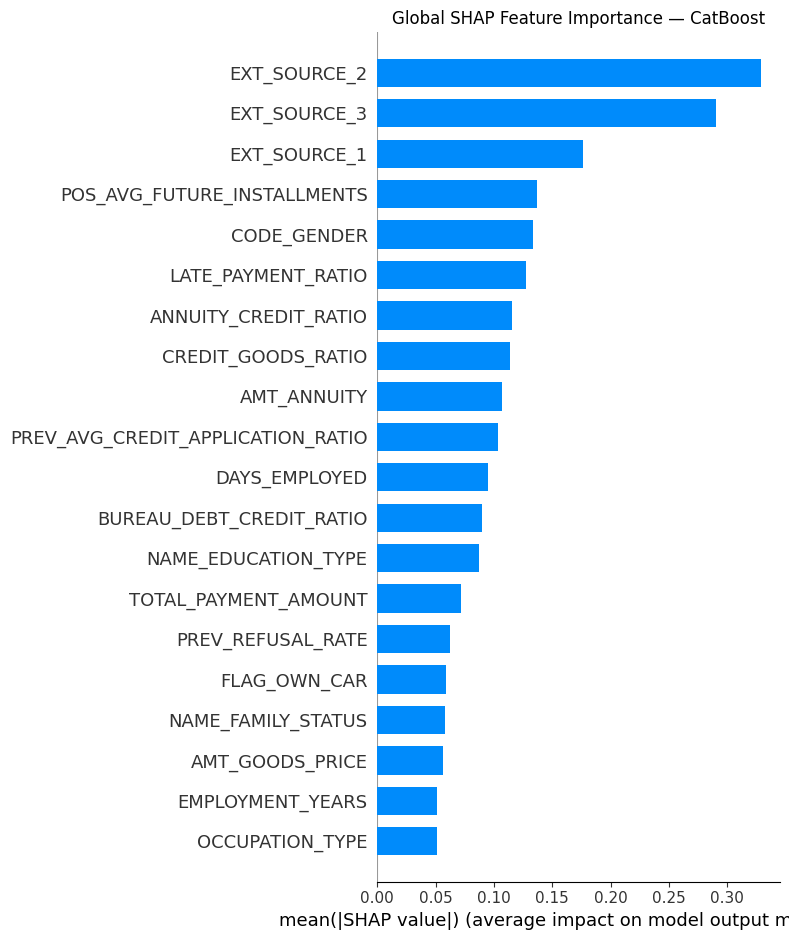

In [150]:
# GLOBAL SHAP FEATURE IMPORTANCE

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort from most important to least important
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Add rank
shap_importance.insert(
    0,
    "Rank",
    range(1, len(shap_importance) + 1)
)



# DISPLAY TOP FEATURES

print("=" * 65)
print("TOP 20 FEATURES — GLOBAL SHAP IMPORTANCE")
print("=" * 65)

print(
    shap_importance.head(20).to_string(
        index=False
    )
)


# SHAP BAR PLOT

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "Global SHAP Feature Importance — CatBoost"
)

plt.tight_layout()
plt.show()

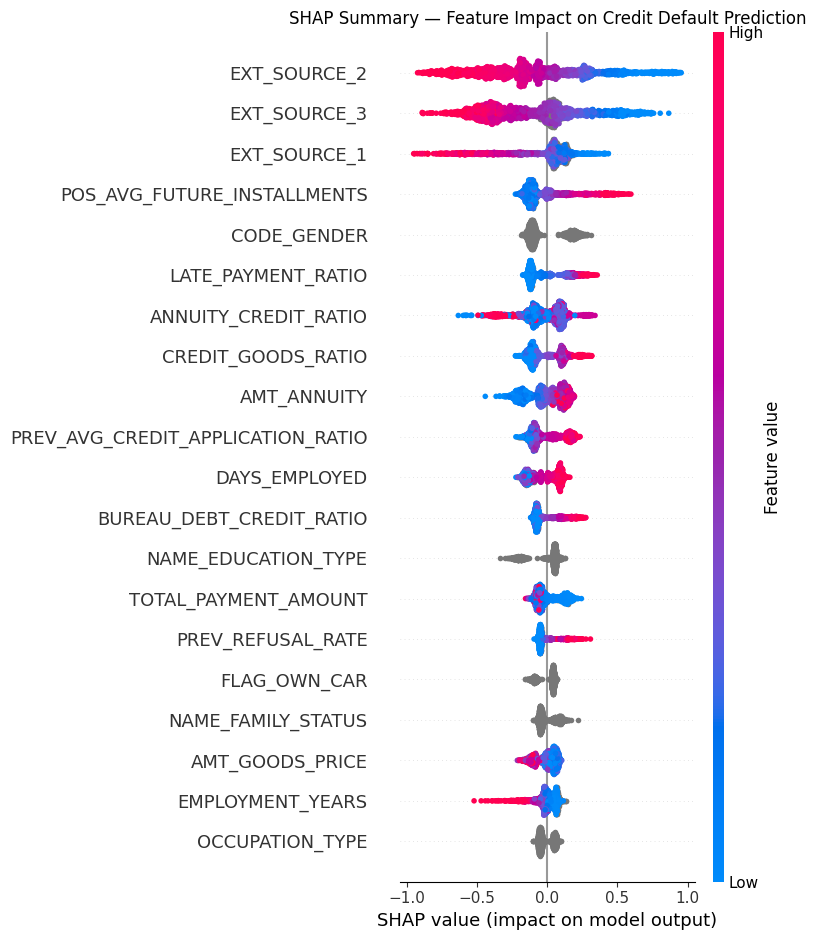

In [151]:
# SHAP BEESWARM PLOT

plt.figure(figsize=(12, 9))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary — Feature Impact on Credit Default Prediction"
)

plt.tight_layout()
plt.show()

## Local SHAP Explanation — Individual Applicant

Global SHAP analysis identifies the features that influence the model across the dataset. Local SHAP analysis explains the prediction for a specific applicant.

For an individual applicant, SHAP values show which features contributed to increasing or decreasing the predicted default risk. This enables the credit-risk platform to provide transparent, applicant-specific explanations rather than only returning a prediction.

In [152]:
# LOCAL SHAP EXPLANATION — ONE APPLICANT

# Select one validation applicant
applicant_index = X_valid.index[0]

applicant = X_valid.loc[[applicant_index]]

# Get model prediction
applicant_probability = catboost_model.predict_proba(
    applicant
)[:, 1][0]

# Calculate SHAP values for this applicant
applicant_shap = explainer.shap_values(
    applicant
)[0]

# Create explanation dataframe
local_explanation = pd.DataFrame({
    "Feature": applicant.columns,
    "Feature_Value": applicant.iloc[0].values,
    "SHAP_Value": applicant_shap
})

# Absolute importance
local_explanation["Absolute_SHAP"] = (
    local_explanation["SHAP_Value"].abs()
)

# Sort by absolute contribution
local_explanation = local_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
).reset_index(drop=True)


# TOP RISK-INCREASING FEATURES

risk_increasing = (
    local_explanation[
        local_explanation["SHAP_Value"] > 0
    ]
    .sort_values("SHAP_Value", ascending=False)
    .head(10)
)


# TOP RISK-REDUCING FEATURES

risk_reducing = (
    local_explanation[
        local_explanation["SHAP_Value"] < 0
    ]
    .sort_values("SHAP_Value", ascending=True)
    .head(10)
)


# DISPLAY

print("=" * 70)
print("LOCAL SHAP EXPLANATION")
print("=" * 70)

print(f"\nApplicant index: {applicant_index}")
print(f"Predicted default probability: {applicant_probability:.4f}")
print(f"Predicted default probability: {applicant_probability * 100:.2f}%")

print("\n" + "-" * 70)
print("TOP FEATURES INCREASING DEFAULT RISK")
print("-" * 70)

print(
    risk_increasing[
        ["Feature", "Feature_Value", "SHAP_Value"]
    ].to_string(index=False)
)

print("\n" + "-" * 70)
print("TOP FEATURES REDUCING DEFAULT RISK")
print("-" * 70)

print(
    risk_reducing[
        ["Feature", "Feature_Value", "SHAP_Value"]
    ].to_string(index=False)
)

LOCAL SHAP EXPLANATION

Applicant index: 256571
Predicted default probability: 0.2283
Predicted default probability: 22.83%

----------------------------------------------------------------------
TOP FEATURES INCREASING DEFAULT RISK
----------------------------------------------------------------------
             Feature Feature_Value  SHAP_Value
         CODE_GENDER             M      0.1577
        EXT_SOURCE_1           NaN      0.1244
TOTAL_PAYMENT_AMOUNT    87012.5400      0.1011
 BUREAU_ACTIVE_COUNT        4.0000      0.0951
         AMT_ANNUITY    30676.5000      0.0938
    EMPLOYMENT_YEARS        0.2875      0.0901
       DAYS_EMPLOYED     -105.0000      0.0853
          DAYS_BIRTH        -13506      0.0572
    PREV_AVG_ANNUITY     6589.0650      0.0552
           AGE_YEARS       36.9774      0.0552

----------------------------------------------------------------------
TOP FEATURES REDUCING DEFAULT RISK
----------------------------------------------------------------------
 

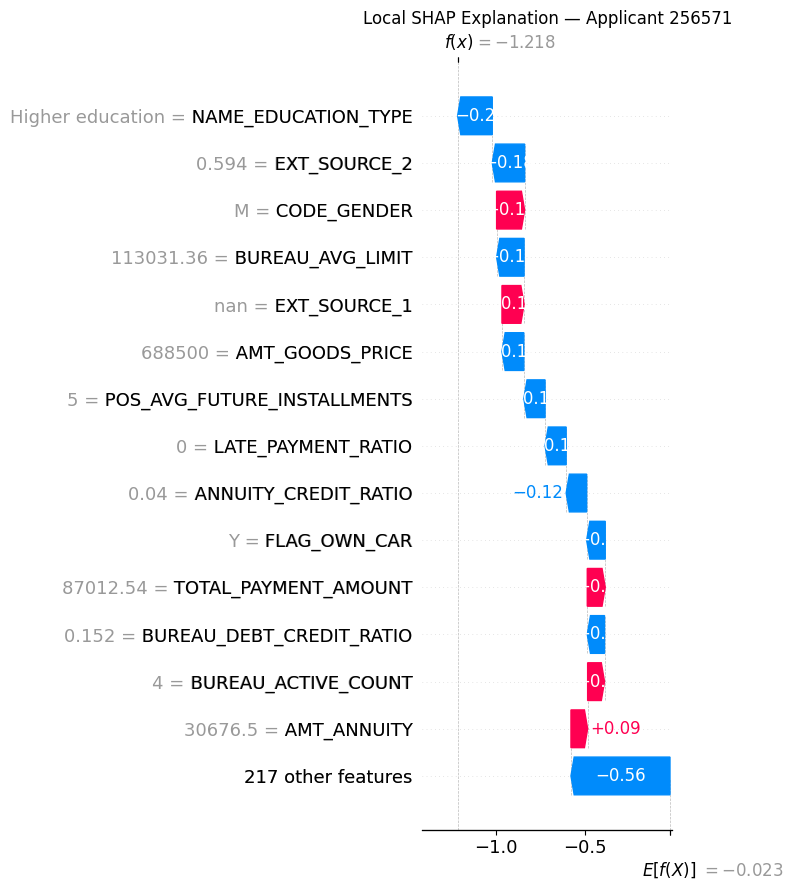

In [153]:
# LOCAL SHAP WATERFALL PLOT

# Create an Explanation object for the selected applicant
applicant_explanation = shap.Explanation(
    values=applicant_shap,
    base_values=explainer.expected_value,
    data=applicant.iloc[0].values,
    feature_names=applicant.columns.tolist()
)


# Waterfall plot

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    applicant_explanation,
    max_display=15,
    show=False
)

plt.title(
    f"Local SHAP Explanation — Applicant {applicant_index}"
)

plt.tight_layout()
plt.show()

## Business-Readable Risk Explanation

Raw SHAP values are useful for technical model analysis but are not directly suitable for end users.

The platform therefore converts the strongest positive and negative SHAP contributions into business-readable explanations. Positive SHAP values represent factors that increase the model's predicted default risk, while negative SHAP values represent factors that reduce it.

These explanations describe model associations and are not interpreted as causal relationships.

In [157]:
# BUSINESS-READABLE SHAP EXPLANATION

# Helper function for formatting feature values

def format_feature_value(feature, value):

    if pd.isna(value):
        return "missing"

    if feature in [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]:
        return f"{float(value):.3f}"

    if "RATIO" in feature:
        return f"{float(value):.2f}"

    if feature in [
        "AGE_YEARS",
        "EMPLOYMENT_YEARS"
    ]:
        return f"{float(value):.1f} years"

    if feature in [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "TOTAL_PAYMENT_AMOUNT",
        "BUREAU_AVG_LIMIT"
    ]:
        return f"{float(value):,.0f}"

    if isinstance(value, (float, np.floating)):
        return f"{float(value):.2f}"

    return str(value)


# Feature → business description

feature_descriptions = {

    "EXT_SOURCE_1":
        "External credit score 1",

    "EXT_SOURCE_2":
        "External credit score 2",

    "EXT_SOURCE_3":
        "External credit score 3",

    "POS_AVG_FUTURE_INSTALLMENTS":
        "Average number of future installments",

    "LATE_PAYMENT_RATIO":
        "Historical late-payment frequency",

    "ANNUITY_CREDIT_RATIO":
        "Loan annuity relative to credit amount",

    "CREDIT_GOODS_RATIO":
        "Credit amount relative to goods price",

    "AMT_ANNUITY":
        "Loan annuity amount",

    "PREV_AVG_CREDIT_APPLICATION_RATIO":
        "Historical credit-to-application ratio",

    "DAYS_EMPLOYED":
        "Employment duration",

    "EMPLOYMENT_YEARS":
        "Employment duration",

    "BUREAU_DEBT_CREDIT_RATIO":
        "Historical debt relative to credit",

    "TOTAL_PAYMENT_AMOUNT":
        "Historical total payment amount",

    "PREV_REFUSAL_RATE":
        "Previous application refusal rate",

    "BUREAU_ACTIVE_COUNT":
        "Number of active historical credits",

    "BUREAU_AVG_LIMIT":
        "Average historical credit limit",

    "AMT_GOODS_PRICE":
        "Price of goods financed",

    "NAME_EDUCATION_TYPE":
        "Education level",

    "FLAG_OWN_CAR":
        "Car ownership",

    "CODE_GENDER":
        "Gender",

    "AMT_REQ_CREDIT_BUREAU_QRT":
        "Recent credit-bureau inquiries"
}


# Generate readable explanations

business_increasing = []

for _, row in risk_increasing.iterrows():

    feature = row["Feature"]
    value = row["Feature_Value"]

    description = feature_descriptions.get(
        feature,
        feature.replace("_", " ").title()
    )

    formatted_value = format_feature_value(
        feature,
        value
    )

    business_increasing.append(
        f"{description} ({formatted_value}) "
        f"contributed to higher predicted risk."
    )


business_reducing = []

for _, row in risk_reducing.iterrows():

    feature = row["Feature"]
    value = row["Feature_Value"]

    description = feature_descriptions.get(
        feature,
        feature.replace("_", " ").title()
    )

    formatted_value = format_feature_value(
        feature,
        value
    )

    business_reducing.append(
        f"{description} ({formatted_value}) "
        f"contributed to lower predicted risk."
    )


# FINAL APPLICANT EXPLANATION

print("=" * 70)
print("BUSINESS-READABLE CREDIT RISK EXPLANATION")
print("=" * 70)

print(
    f"\nApplicant: {applicant_index}"
)

print(
    f"Estimated default probability: "
    f"{applicant_probability * 100:.2f}%"
)

print(
    f"Classification threshold: "
    f"{FINAL_THRESHOLD * 100:.0f}%"
)

if applicant_probability >= FINAL_THRESHOLD:
    prediction_label = "Predicted Default"
else:
    prediction_label = "Predicted Non-Default"

print(
    f"Model prediction: {prediction_label}"
)


print("\n" + "-" * 70)
print("FACTORS INCREASING PREDICTED RISK")
print("-" * 70)

for reason in business_increasing[:5]:
    print("•", reason)


print("\n" + "-" * 70)
print("FACTORS REDUCING PREDICTED RISK")
print("-" * 70)

for reason in business_reducing[:5]:
    print("•", reason)

BUSINESS-READABLE CREDIT RISK EXPLANATION

Applicant: 256571
Estimated default probability: 22.83%
Classification threshold: 66%
Model prediction: Predicted Non-Default

----------------------------------------------------------------------
FACTORS INCREASING PREDICTED RISK
----------------------------------------------------------------------
• Gender (M) contributed to higher predicted risk.
• External credit score 1 (missing) contributed to higher predicted risk.
• Historical total payment amount (87,013) contributed to higher predicted risk.
• Number of active historical credits (4.00) contributed to higher predicted risk.
• Loan annuity amount (30,676) contributed to higher predicted risk.

----------------------------------------------------------------------
FACTORS REDUCING PREDICTED RISK
----------------------------------------------------------------------
• Education level (Higher education) contributed to lower predicted risk.
• External credit score 2 (0.594) contributed t

## User-Facing Risk Explanation

The technical SHAP analysis considers all model features to explain the model's behaviour. However, not every model feature is appropriate as a user-facing credit-risk reason.

The platform therefore filters out sensitive or non-actionable attributes from the final explanation and focuses on financial, repayment, credit-history, and employment-related factors.

This separation allows the system to retain complete model explainability for technical evaluation while providing clearer and more responsible explanations to end users.

In [158]:
# USER-FACING SHAP EXPLANATION

# Features excluded from user-facing explanations
# but retained in the technical SHAP analysis.

excluded_explanation_features = {
    "CODE_GENDER",
    "NAME_FAMILY_STATUS",
    "NAME_EDUCATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
}


# Filter technical SHAP explanations

user_facing_explanation = local_explanation[
    ~local_explanation["Feature"].isin(
        excluded_explanation_features
    )
].copy()


# Separate positive and negative contributors

user_risk_increasing = (
    user_facing_explanation[
        user_facing_explanation["SHAP_Value"] > 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
    .head(5)
)


user_risk_reducing = (
    user_facing_explanation[
        user_facing_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=True
    )
    .head(5)
)


# DISPLAY FINAL USER-FACING EXPLANATION

print("=" * 70)
print("USER-FACING CREDIT RISK EXPLANATION")
print("=" * 70)

print(
    f"\nApplicant: {applicant_index}"
)

print(
    f"Estimated default probability: "
    f"{applicant_probability * 100:.2f}%"
)

print(
    f"Classification threshold: "
    f"{FINAL_THRESHOLD * 100:.0f}%"
)

prediction = (
    "Predicted Default"
    if applicant_probability >= FINAL_THRESHOLD
    else "Predicted Non-Default"
)

print(
    f"Model prediction: {prediction}"
)


print("\n" + "-" * 70)
print("MAIN FACTORS INCREASING PREDICTED RISK")
print("-" * 70)

for _, row in user_risk_increasing.iterrows():

    feature = row["Feature"]

    description = feature_descriptions.get(
        feature,
        feature.replace("_", " ").title()
    )

    value = format_feature_value(
        feature,
        row["Feature_Value"]
    )

    print(
        f"• {description}: {value}"
    )


print("\n" + "-" * 70)
print("MAIN FACTORS REDUCING PREDICTED RISK")
print("-" * 70)

for _, row in user_risk_reducing.iterrows():

    feature = row["Feature"]

    description = feature_descriptions.get(
        feature,
        feature.replace("_", " ").title()
    )

    value = format_feature_value(
        feature,
        row["Feature_Value"]
    )

    print(
        f"• {description}: {value}"
    )

USER-FACING CREDIT RISK EXPLANATION

Applicant: 256571
Estimated default probability: 22.83%
Classification threshold: 66%
Model prediction: Predicted Non-Default

----------------------------------------------------------------------
MAIN FACTORS INCREASING PREDICTED RISK
----------------------------------------------------------------------
• External credit score 1: missing
• Historical total payment amount: 87,013
• Number of active historical credits: 4.00
• Loan annuity amount: 30,676
• Employment duration: 0.3 years

----------------------------------------------------------------------
MAIN FACTORS REDUCING PREDICTED RISK
----------------------------------------------------------------------
• External credit score 2: 0.594
• Average historical credit limit: 113,031
• Price of goods financed: 688,500
• Average number of future installments: 5.00
• Historical late-payment frequency: 0.00


## Credit Risk Scoring and Risk Bands

The selected CatBoost model produces a probability of default for each applicant.

For easier interpretation, the predicted probability is converted into a 0–100 Risk Score. Applicants are then grouped into three risk bands:

- **Low Risk:** default probability below 30%
- **Medium Risk:** default probability from 30% to below 60%
- **High Risk:** default probability of 60% or higher

The binary default classification uses the tuned validation threshold of 0.66, which was selected because it produced the highest F1 Score during fine-grained threshold evaluation.

Risk bands and classification thresholds are model outputs for this prototype and should not be interpreted as real-world lending policy.

In [159]:
# CREDIT RISK SCORING SYSTEM

# Configuration

RISK_LOW_THRESHOLD = 0.30
RISK_HIGH_THRESHOLD = 0.60

# Tuned binary classification threshold
FINAL_THRESHOLD = float(best_fine["Threshold"])


# Risk-band function

def assign_risk_band(probability):

    if probability < RISK_LOW_THRESHOLD:
        return "Low"

    elif probability < RISK_HIGH_THRESHOLD:
        return "Medium"

    else:
        return "High"


# CREATE VALIDATION RISK OUTPUT

risk_results = pd.DataFrame({
    "Applicant_ID": X_valid.index,
    "Actual_Default": y_valid.values,
    "Default_Probability": y_valid_prob_catboost
})

# Risk score: 0–100
risk_results["Risk_Score"] = (
    risk_results["Default_Probability"] * 100
)

# Risk band
risk_results["Risk_Band"] = (
    risk_results["Default_Probability"]
    .apply(assign_risk_band)
)

# Binary model decision
risk_results["Predicted_Default"] = (
    risk_results["Default_Probability"]
    >= FINAL_THRESHOLD
).astype(int)


# DISPLAY SUMMARY

print("=" * 70)
print("CREDIT RISK SCORING SYSTEM")
print("=" * 70)

print(f"\nBinary classification threshold: {FINAL_THRESHOLD:.2f}")
print(f"Low-risk upper boundary       : {RISK_LOW_THRESHOLD:.2f}")
print(f"High-risk lower boundary      : {RISK_HIGH_THRESHOLD:.2f}")


print("\n" + "-" * 70)
print("RISK BAND DISTRIBUTION")
print("-" * 70)

print(
    risk_results["Risk_Band"]
    .value_counts()
)


print("\nRisk band percentages:")

print(
    risk_results["Risk_Band"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# EXAMPLE APPLICANTS

print("\n" + "-" * 70)
print("SAMPLE RISK PREDICTIONS")
print("-" * 70)

print(
    risk_results[
        [
            "Applicant_ID",
            "Default_Probability",
            "Risk_Score",
            "Risk_Band",
            "Predicted_Default"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

CREDIT RISK SCORING SYSTEM

Binary classification threshold: 0.66
Low-risk upper boundary       : 0.30
High-risk lower boundary      : 0.60

----------------------------------------------------------------------
RISK BAND DISTRIBUTION
----------------------------------------------------------------------
Risk_Band
Low       28809
Medium    22152
High      10542
Name: count, dtype: int64

Risk band percentages:
Risk_Band
Low      46.8400
Medium   36.0200
High     17.1400
Name: proportion, dtype: float64

----------------------------------------------------------------------
SAMPLE RISK PREDICTIONS
----------------------------------------------------------------------
 Applicant_ID  Default_Probability  Risk_Score Risk_Band  Predicted_Default
       256571               0.2283     22.8251       Low                  0
       191493               0.3205     32.0484    Medium                  0
       103497               0.7957     79.5728      High                  1
       130646        

## Risk Band Validation

The initial risk bands are evaluated against the observed validation outcomes to verify that higher predicted-risk groups correspond to higher observed default rates.

This provides a practical validation of whether the risk bands meaningfully separate applicants according to their observed default behaviour.

In [160]:
# RISK BAND VALIDATION

risk_band_validation = (
    risk_results
    .groupby("Risk_Band")
    .agg(
        Applicants=("Actual_Default", "count"),
        Defaults=("Actual_Default", "sum"),
        Default_Rate=("Actual_Default", "mean"),
        Average_Risk_Score=("Risk_Score", "mean"),
        Average_Default_Probability=(
            "Default_Probability",
            "mean"
        )
    )
    .reset_index()
)


# Order the risk bands correctly

risk_order = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

risk_band_validation["Order"] = (
    risk_band_validation["Risk_Band"]
    .map(risk_order)
)

risk_band_validation = (
    risk_band_validation
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)


# Format percentages

display_validation = risk_band_validation.copy()

display_validation["Default_Rate"] = (
    display_validation["Default_Rate"] * 100
).round(2)

display_validation["Average_Default_Probability"] = (
    display_validation["Average_Default_Probability"] * 100
).round(2)

display_validation["Average_Risk_Score"] = (
    display_validation["Average_Risk_Score"]
).round(2)


# DISPLAY

print("=" * 75)
print("RISK BAND VALIDATION")
print("=" * 75)

print(
    display_validation.to_string(index=False)
)


# MONOTONICITY CHECK

default_rates = (
    risk_band_validation["Default_Rate"]
    .tolist()
)

bands_are_monotonic = (
    default_rates == sorted(default_rates)
)

print("\n" + "-" * 75)

if bands_are_monotonic:
    print(
        "✓ Risk bands show increasing observed default rates "
        "from Low → Medium → High."
    )
else:
    print(
        "⚠ Risk bands are not perfectly monotonic. "
        "Review the band boundaries."
    )

RISK BAND VALIDATION
Risk_Band  Applicants  Defaults  Default_Rate  Average_Risk_Score  Average_Default_Probability
      Low       28809       638        2.2100             17.0900                      17.0900
   Medium       22152      1724        7.7800             43.2800                      43.2800
     High       10542      2603       24.6900             72.9700                      72.9700

---------------------------------------------------------------------------
✓ Risk bands show increasing observed default rates from Low → Medium → High.


## Business Decision Rules

The model output is converted into a business-readable recommendation using the validated risk bands.

- **Low Risk (<30% predicted default probability):** Approve / Low Risk
- **Medium Risk (30%–<60%):** Manual Review
- **High Risk (≥60%):** High Risk / Reject Recommendation

These rules are intended for demonstration of the decision-support capability of the prototype. They are not intended to represent real-world lending policy or an automated lending decision.

The system provides a risk assessment and recommendation that can support human decision-making.

In [161]:
# BUSINESS DECISION RULES

def assign_decision(risk_band):

    if risk_band == "Low":
        return "Approve / Low Risk"

    elif risk_band == "Medium":
        return "Manual Review"

    else:
        return "High Risk / Reject Recommendation"


# Apply decision rules

risk_results["Decision"] = (
    risk_results["Risk_Band"]
    .apply(assign_decision)
)


# DECISION DISTRIBUTION

print("=" * 70)
print("BUSINESS DECISION DISTRIBUTION")
print("=" * 70)

print(
    risk_results["Decision"]
    .value_counts()
)


print("\nDecision percentages:")

print(
    risk_results["Decision"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# COMPLETE RISK SUMMARY

print("\n" + "-" * 70)
print("SAMPLE BUSINESS RISK OUTPUT")
print("-" * 70)

print(
    risk_results[
        [
            "Applicant_ID",
            "Default_Probability",
            "Risk_Score",
            "Risk_Band",
            "Predicted_Default",
            "Decision"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

BUSINESS DECISION DISTRIBUTION
Decision
Approve / Low Risk                   28809
Manual Review                        22152
High Risk / Reject Recommendation    10542
Name: count, dtype: int64

Decision percentages:
Decision
Approve / Low Risk                  46.8400
Manual Review                       36.0200
High Risk / Reject Recommendation   17.1400
Name: proportion, dtype: float64

----------------------------------------------------------------------
SAMPLE BUSINESS RISK OUTPUT
----------------------------------------------------------------------
 Applicant_ID  Default_Probability  Risk_Score Risk_Band  Predicted_Default                          Decision
       256571               0.2283     22.8251       Low                  0                Approve / Low Risk
       191493               0.3205     32.0484    Medium                  0                     Manual Review
       103497               0.7957     79.5728      High                  1 High Risk / Reject Recommendati

## End-to-End Credit Risk Prediction

The final prediction pipeline combines the selected CatBoost model, probability-based risk scoring, risk-band classification, business decision rules, and SHAP-based explanations into a reusable prediction function.

This function provides a single interface for generating a complete credit-risk assessment for an applicant.

In [163]:
# END-TO-END CREDIT RISK PREDICTION

def predict_credit_risk(applicant):

    # Ensure DataFrame format

    if isinstance(applicant, pd.Series):
        applicant = applicant.to_frame().T

    applicant = applicant.copy()


    # Remove ID if present

    applicant_id = None

    if "SK_ID_CURR" in applicant.columns:
        applicant_id = applicant["SK_ID_CURR"].iloc[0]
        applicant = applicant.drop(columns=["SK_ID_CURR"])


    # Apply same feature engineering

    applicant["CREDIT_INCOME_RATIO"] = (
        applicant["AMT_CREDIT"] /
        applicant["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    applicant["ANNUITY_INCOME_RATIO"] = (
        applicant["AMT_ANNUITY"] /
        applicant["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    applicant["GOODS_INCOME_RATIO"] = (
        applicant["AMT_GOODS_PRICE"] /
        applicant["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    applicant["ANNUITY_CREDIT_RATIO"] = (
        applicant["AMT_ANNUITY"] /
        applicant["AMT_CREDIT"].replace(0, np.nan)
    )

    applicant["CREDIT_GOODS_RATIO"] = (
        applicant["AMT_CREDIT"] /
        applicant["AMT_GOODS_PRICE"].replace(0, np.nan)
    )


    # Age / employment

    applicant["AGE_YEARS"] = (
        -applicant["DAYS_BIRTH"]
    ) / 365.25

    applicant["DAYS_EMPLOYED"] = (
        applicant["DAYS_EMPLOYED"]
        .replace(365243, np.nan)
    )

    applicant["EMPLOYMENT_YEARS"] = (
        -applicant["DAYS_EMPLOYED"]
    ) / 365.25


    # Family / income

    applicant["INCOME_PER_FAMILY_MEMBER"] = (
        applicant["AMT_INCOME_TOTAL"] /
        applicant["CNT_FAM_MEMBERS"].replace(0, np.nan)
    )

    applicant["INCOME_PER_CHILD"] = (
        applicant["AMT_INCOME_TOTAL"] /
        (applicant["CNT_CHILDREN"] + 1)
    )


    # Documents

    doc_cols = [
        col for col in applicant.columns
        if col.startswith("FLAG_DOCUMENT_")
    ]

    applicant["DOCUMENTS_PROVIDED_COUNT"] = (
        applicant[doc_cols].sum(axis=1)
    )


    # Historical availability

    applicant["HAS_CC_HISTORY"] = (
        applicant["CC_CONTRACT_COUNT"]
        .notna()
        .astype("int8")
    )

    applicant["HAS_BUREAU_HISTORY"] = (
        applicant["BUREAU_CREDIT_COUNT"]
        .notna()
        .astype("int8")
    )

    applicant["HAS_PREVIOUS_APPLICATION"] = (
        applicant["PREV_APP_COUNT"]
        .notna()
        .astype("int8")
    )

    applicant["HAS_POS_HISTORY"] = (
        applicant["POS_CONTRACT_COUNT"]
        .notna()
        .astype("int8")
    )

    applicant["HAS_INSTALLMENT_HISTORY"] = (
        applicant["INSTALLMENT_COUNT"]
        .notna()
        .astype("int8")
    )


    # Bureau ratios

    applicant["BUREAU_DEBT_CREDIT_RATIO"] = (
        applicant["BUREAU_TOTAL_DEBT"] /
        applicant["BUREAU_TOTAL_CREDIT"].replace(
            0,
            np.nan
        )
    )

    applicant["BUREAU_OVERDUE_CREDIT_RATIO"] = (
        applicant["BUREAU_TOTAL_OVERDUE"] /
        applicant["BUREAU_TOTAL_CREDIT"].replace(
            0,
            np.nan
        )
    )


    # Clean values

    applicant = applicant.replace(
        [np.inf, -np.inf],
        np.nan
    )


    # Ensure expected feature order

    applicant = applicant.reindex(
        columns=X.columns
    )


    # Categorical handling

    for col in categorical_cols:

        applicant[col] = (
            applicant[col]
            .fillna("Missing")
            .astype(str)
        )


    # CATBOOST PREDICTION

    probability = catboost_model.predict_proba(
        applicant
    )[:, 1][0]


    # Risk score

    risk_score = probability * 100


    # Risk band

    risk_band = assign_risk_band(
        probability
    )


    # Binary prediction

    predicted_default = int(
        probability >= FINAL_THRESHOLD
    )


    # Business decision

    decision = assign_decision(
        risk_band
    )


    # RETURN RESULT

    return {
        "Applicant_ID": applicant_id,
        "Default_Probability": probability,
        "Risk_Score": risk_score,
        "Risk_Band": risk_band,
        "Predicted_Default": predicted_default,
        "Decision": decision
    }

In [164]:
# TEST END-TO-END PREDICTION

test_applicant = X_valid.loc[
    [applicant_index]
].copy()

# X_valid no longer contains SK_ID_CURR,
# so add the known applicant ID separately
test_applicant["SK_ID_CURR"] = applicant_index

prediction_result = predict_credit_risk(
    test_applicant
)

print("=" * 70)
print("END-TO-END CREDIT RISK PREDICTION")
print("=" * 70)

for key, value in prediction_result.items():
    print(f"{key}: {value}")

END-TO-END CREDIT RISK PREDICTION
Applicant_ID: 256571
Default_Probability: 0.22825077797975887
Risk_Score: 22.825077797975887
Risk_Band: Low
Predicted_Default: 0
Decision: Approve / Low Risk


In [165]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# Final CatBoost validation probabilities
y_valid_proba = catboost_model.predict_proba(X_valid)[:, 1]

# Apply selected threshold
y_valid_pred = (y_valid_proba >= FINAL_THRESHOLD).astype(int)

# Metrics
final_roc_auc = roc_auc_score(y_valid, y_valid_proba)
final_pr_auc = average_precision_score(y_valid, y_valid_proba)
final_precision = precision_score(y_valid, y_valid_pred)
final_recall = recall_score(y_valid, y_valid_pred)
final_f1 = f1_score(y_valid, y_valid_pred)

print("=" * 70)
print("FINAL CATBOOST VALIDATION RESULTS")
print("=" * 70)

print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=["Non-Default", "Default"],
    digits=4
))

FINAL CATBOOST VALIDATION RESULTS
ROC-AUC   : 0.7878
PR-AUC    : 0.2862
Precision : 0.2824
Recall    : 0.4354
F1 Score  : 0.3426

Confusion Matrix:
[[51044  5494]
 [ 2803  2162]]

Classification Report:
              precision    recall  f1-score   support

 Non-Default     0.9479    0.9028    0.9248     56538
     Default     0.2824    0.4354    0.3426      4965

    accuracy                         0.8651     61503
   macro avg     0.6152    0.6691    0.6337     61503
weighted avg     0.8942    0.8651    0.8778     61503



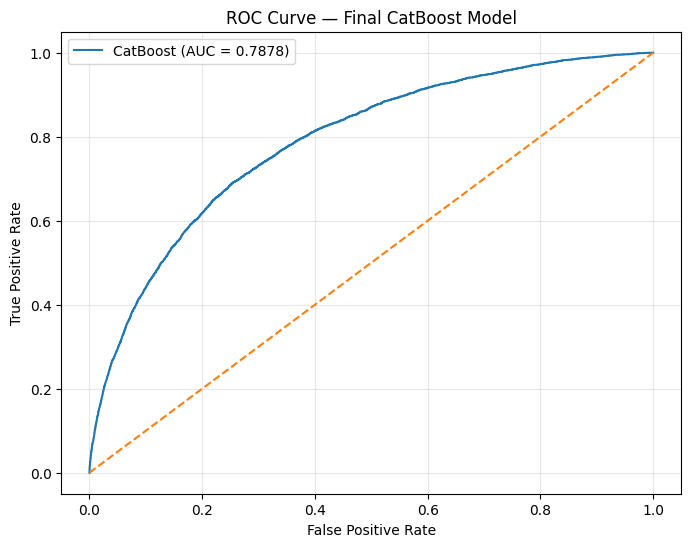

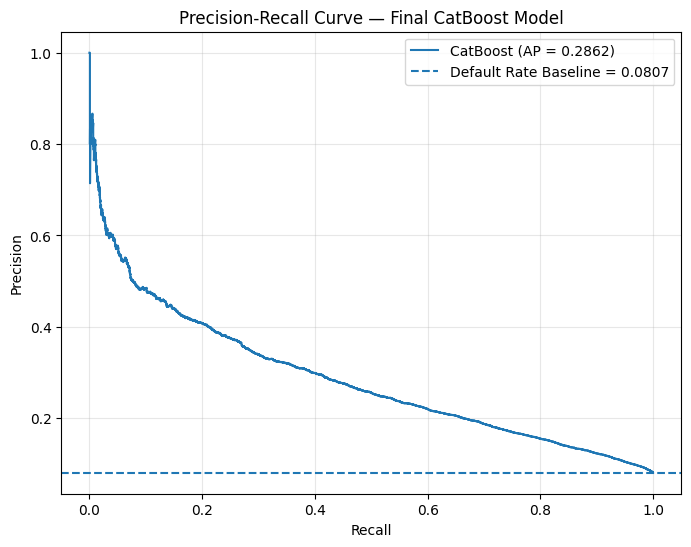

In [166]:
# ROC CURVE

fpr, tpr, roc_thresholds = roc_curve(y_valid, y_valid_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {final_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final CatBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# PRECISION-RECALL CURVE

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_valid,
    y_valid_proba
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"CatBoost (AP = {final_pr_auc:.4f})"
)

# Default-rate baseline
baseline = y_valid.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Default Rate Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final CatBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [167]:
# SAVE FINAL ML ARTIFACTS

import os
import json
import joblib

ARTIFACT_DIR = "credit_risk_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1. Save CatBoost model

MODEL_PATH = os.path.join(ARTIFACT_DIR, "catboost_credit_risk_model.cbm")

catboost_model.save_model(MODEL_PATH)


# 2. Save final feature column names

FEATURE_COLUMNS_PATH = os.path.join(
    ARTIFACT_DIR,
    "feature_columns.pkl"
)

joblib.dump(
    list(X.columns),
    FEATURE_COLUMNS_PATH
)


# 3. Save risk configuration

risk_config = {
    "classification_threshold": float(FINAL_THRESHOLD),

    "risk_bands": {
        "Low": {
            "min_probability": 0.0,
            "max_probability": 0.30
        },
        "Medium": {
            "min_probability": 0.30,
            "max_probability": 0.60
        },
        "High": {
            "min_probability": 0.60,
            "max_probability": 1.0
        }
    },

    "decisions": {
        "Low": "Approve / Low Risk",
        "Medium": "Manual Review",
        "High": "High Risk / Reject Recommendation"
    }
}

RISK_CONFIG_PATH = os.path.join(
    ARTIFACT_DIR,
    "risk_config.json"
)

with open(RISK_CONFIG_PATH, "w") as f:
    json.dump(risk_config, f, indent=4)


# 4. Save model metadata

model_metadata = {
    "model": "CatBoost",
    "selection_metric": "PR-AUC",
    "validation_roc_auc": float(final_roc_auc),
    "validation_pr_auc": float(final_pr_auc),
    "validation_precision": float(final_precision),
    "validation_recall": float(final_recall),
    "validation_f1": float(final_f1),
    "classification_threshold": float(FINAL_THRESHOLD),
    "training_rows": int(len(X_train)),
    "validation_rows": int(len(X_valid)),
    "feature_count": int(len(X.columns)),
    "positive_class_ratio": float(y.mean())
}

METADATA_PATH = os.path.join(
    ARTIFACT_DIR,
    "model_metadata.json"
)

with open(METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=4)


# 5. Verify saved files

print("=" * 70)
print("ML ARTIFACTS SAVED")
print("=" * 70)

for filename in os.listdir(ARTIFACT_DIR):
    filepath = os.path.join(ARTIFACT_DIR, filename)
    print(f"{filename:<40} {os.path.getsize(filepath) / (1024**2):.2f} MB")

ML ARTIFACTS SAVED
catboost_credit_risk_model.cbm           2.12 MB
model_metadata.json                      0.00 MB
feature_columns.pkl                      0.00 MB
risk_config.json                         0.00 MB


In [168]:
# LOAD SAVED MODEL AND VERIFY INFERENCE

import os
import json
import joblib
from catboost import CatBoostClassifier

ARTIFACT_DIR = "credit_risk_artifacts"

# Load model

loaded_model = CatBoostClassifier()

loaded_model.load_model(
    os.path.join(
        ARTIFACT_DIR,
        "catboost_credit_risk_model.cbm"
    )
)

# Load feature configuration
saved_feature_columns = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "feature_columns.pkl"
    )
)

with open(
    os.path.join(
        ARTIFACT_DIR,
        "risk_config.json"
    ),
    "r"
) as f:
    loaded_risk_config = json.load(f)


# Verify feature structure

print("=" * 70)
print("SAVED MODEL VERIFICATION")
print("=" * 70)

print(f"Model loaded successfully : {loaded_model is not None}")
print(f"Saved feature count       : {len(saved_feature_columns)}")
print(f"Current feature count     : {len(X.columns)}")
print(
    f"Feature order matches     : "
    f"{list(X.columns) == saved_feature_columns}"
)

print(
    f"Saved threshold           : "
    f"{loaded_risk_config['classification_threshold']}"
)

# Test inference using a validation applicant

test_idx = 256571

test_row = X_valid.loc[[test_idx]].copy()

# Ensure exact training feature order
test_row = test_row[saved_feature_columns]

loaded_probability = loaded_model.predict_proba(
    test_row
)[:, 1][0]

loaded_score = loaded_probability * 100

threshold = loaded_risk_config["classification_threshold"]

if loaded_probability < 0.30:
    loaded_band = "Low"
elif loaded_probability < 0.60:
    loaded_band = "Medium"
else:
    loaded_band = "High"

loaded_prediction = int(
    loaded_probability >= threshold
)

loaded_decision = loaded_risk_config["decisions"][
    loaded_band
]

print("\n" + "=" * 70)
print("LOADED MODEL INFERENCE")
print("=" * 70)

print(f"Applicant ID        : {test_idx}")
print(f"Default Probability : {loaded_probability:.6f}")
print(f"Risk Score          : {loaded_score:.2f}")
print(f"Risk Band           : {loaded_band}")
print(f"Predicted Default   : {loaded_prediction}")
print(f"Decision            : {loaded_decision}")

SAVED MODEL VERIFICATION
Model loaded successfully : True
Saved feature count       : 231
Current feature count     : 231
Feature order matches     : True
Saved threshold           : 0.6600000000000001

LOADED MODEL INFERENCE
Applicant ID        : 256571
Default Probability : 0.228251
Risk Score          : 22.83
Risk Band           : Low
Predicted Default   : 0
Decision            : Approve / Low Risk


In [169]:
import joblib
import os

joblib.dump(
    categorical_cols,
    os.path.join(
        ARTIFACT_DIR,
        "categorical_columns.pkl"
    )
)

print("Categorical columns saved:", len(categorical_cols))

Categorical columns saved: 16
